# NLP Coursework Notebook

In [ ]:
!pip install -r requirements.txt

In [ ]:
# ===============================
# Imports
# ===============================
from IPython.display import display, Markdown
from __future__ import annotations
from collections import Counter
from contextlib import redirect_stdout
from datasets import load_dataset, Features, Sequence, ClassLabel, Value
from datetime import datetime
from gensim.models import FastText
from gensim.models import Word2Vec
from io import StringIO
from itertools import chain
from nltk import pos_tag
from nltk.stem import PorterStemmer
from optuna.visualization.matplotlib import plot_optimization_history
from pathlib import Path
from seqeval.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from seqeval.metrics import classification_report, f1_score
from seqeval.scheme import IOB2
from sklearn.metrics import classification_report as sk_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report as sk_report,
)
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import CRF
from torch import nn
from torch import nn, optim
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.utils.data import DataLoader, Dataset
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from transformers import (
    AutoTokenizer,
    AutoConfig,
    AutoModelForTokenClassification,
    DataCollatorForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)
from transformers import AutoTokenizer, AutoModel
import argparse, os, random, json, warnings
import argparse, random, json, warnings
import collections
import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import os
import os, random, numpy as np, torch, optuna, matplotlib.pyplot as plt
import os, random, tarfile, requests, numpy as np, torch, matplotlib.pyplot as plt, optuna
import pandas as pd
import random
import seaborn as sns
import textwrap
import torch
import torch.nn as nn
import torch.optim as optim
import umap
import warnings

2025-05-15 21:50:02.366192: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 21:50:02.380240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747342202.388219   57963 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747342202.390617   57963 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747342202.396935   57963 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 1. Dataset Analysis and Visualisation

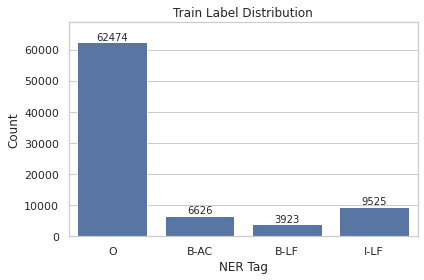

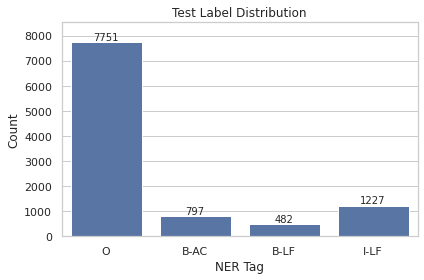

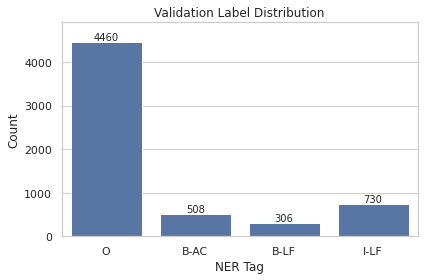

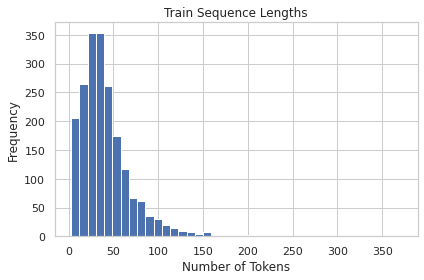

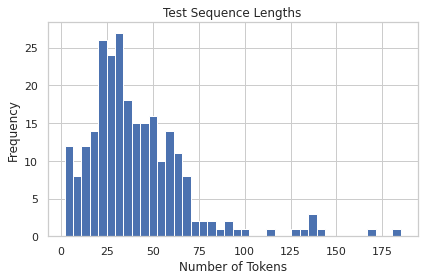

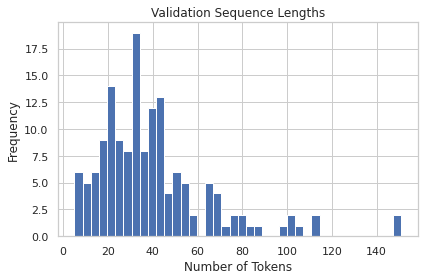

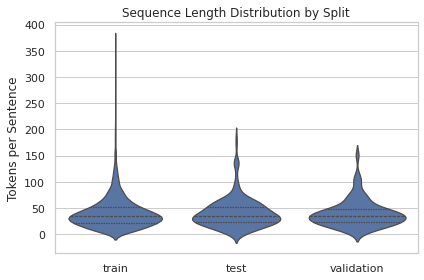

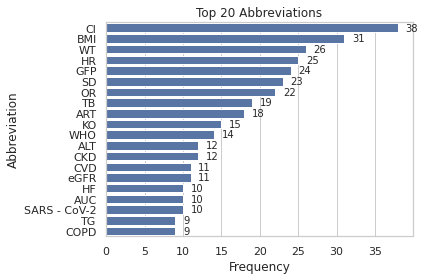

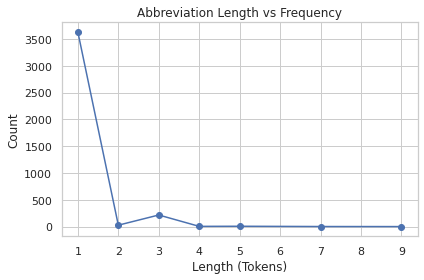

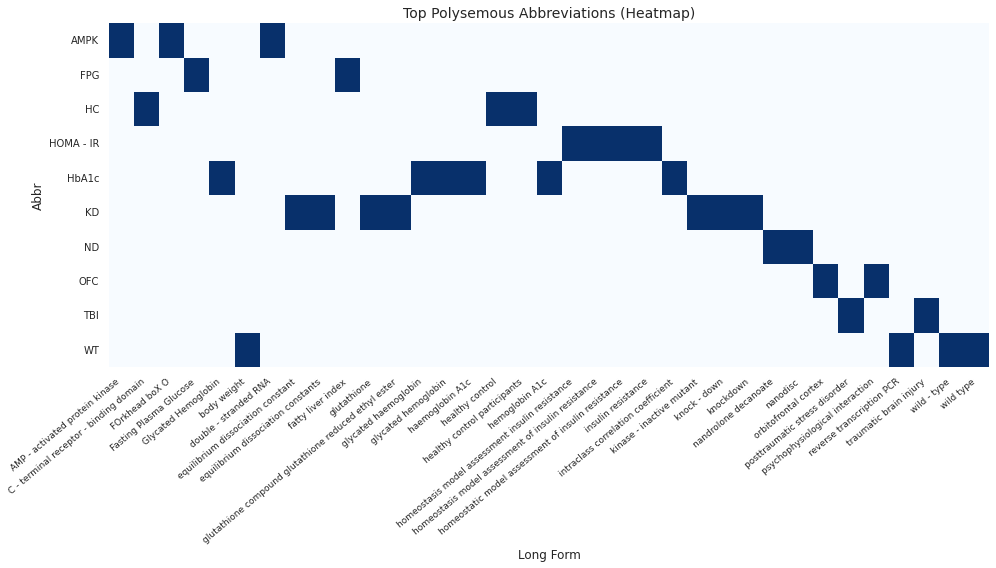

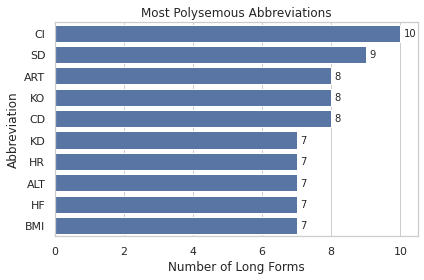

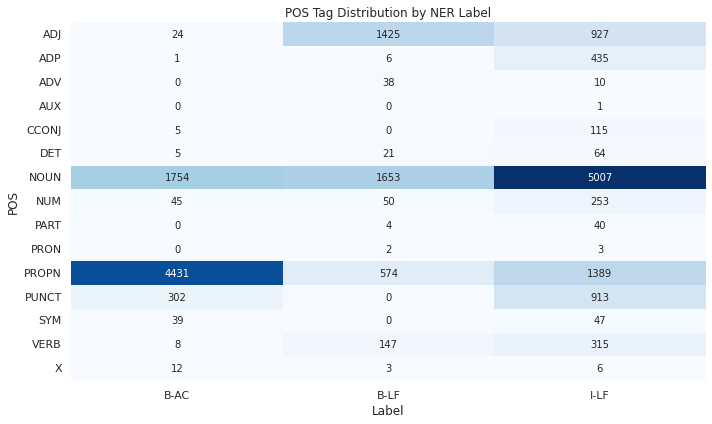

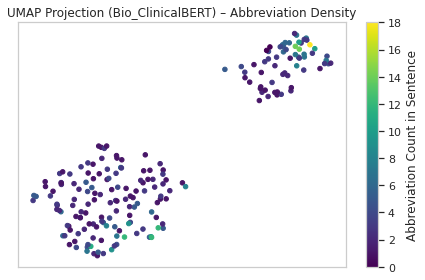

In [ ]:
# =============================================================================
# SECTION 1 — Dataset Analysis & Visualisation
# =============================================================================

# --------------------------------------
# 1. Imports and Configuration
# --------------------------------------

# Suppress warnings
warnings.filterwarnings("ignore")
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# Visualization setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

# Constants
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# --------------------------------------
# 2. Directory Setup and Utilities
# --------------------------------------
BASE_DIR = "SECTION 1 - Dataset Analysis & Visualisation"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)


def save_plot(name: str, fmt: str = "png", dpi: int = 300) -> None:
    """Save matplotlib figure with consistent styling."""
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{name}.{fmt}"), dpi=dpi, bbox_inches="tight")
    plt.show()


# --------------------------------------
# 3. Data Loading
# --------------------------------------
LABEL_NAMES = ["O", "B-AC", "B-LF", "I-LF"]

features = Features(
    {
        "tokens": Sequence(Value("string")),
        "pos_tags": Sequence(Value("string")),
        "ner_tags": Sequence(ClassLabel(names=LABEL_NAMES)),
    }
)

plod = load_dataset("surrey-nlp/PLOD-CW-25", features=features)


# --------------------------------------
# 4. Helper Functions
# --------------------------------------
def flatten(split: str) -> tuple:
    """Flatten tokens and tags for a dataset split."""
    toks, tags = [], []
    for eg in plod[split]:
        toks += eg["tokens"]
        tags += [LABEL_NAMES[i] for i in eg["ner_tags"]]
    return toks, tags


def get_spans(tokens: list, tags: list) -> tuple:
    """Extract abbreviation and long-form spans."""
    abbr, lfs = [], []
    i = 0
    while i < len(tokens):
        if tags[i] == 1:  # B-AC
            j = i
            while j < len(tokens) and tags[j] == 1:
                j += 1
            abbr.append(tokens[i:j])
            i = j
        elif tags[i] == 2:  # B-LF
            j = i + 1
            while j < len(tokens) and tags[j] == 3:  # I-LF
                j += 1
            lfs.append(tokens[i:j])
            i = j
        else:
            i += 1
    return abbr, lfs


# --------------------------------------
# 5. Label Distribution Analysis
# --------------------------------------
for split in plod:
    _, tags = flatten(split)
    ax = sns.countplot(x=tags, order=LABEL_NAMES)
    plt.title(f"{split.capitalize()} Label Distribution")
    plt.xlabel("NER Tag")
    plt.ylabel("Count")

    for p in ax.patches:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
        )
    ax.set_ylim(0, max([p.get_height() for p in ax.patches]) * 1.1)
    save_plot(f"{split}_label_dist")

# --------------------------------------
# 6. Sequence Length Analysis
# --------------------------------------
# Length distributions per split
for split in plod:
    lens = [len(eg["tokens"]) for eg in plod[split]]
    plt.hist(lens, bins=40)
    plt.title(f"{split.capitalize()} Sequence Lengths")
    plt.xlabel("Number of Tokens")
    plt.ylabel("Frequency")
    save_plot(f"{split}_seq_lengths")

# Combined violin plot
seq_len_df = pd.DataFrame(
    [(split, len(eg["tokens"])) for split in plod for eg in plod[split]],
    columns=["Split", "SeqLen"],
)
sns.violinplot(x="Split", y="SeqLen", data=seq_len_df, inner="quartile")
plt.title("Sequence Length Distribution by Split")
plt.xlabel("")
plt.ylabel("Tokens per Sentence")
save_plot("seq_len_violin")

# --------------------------------------
# 7. Abbreviation Analysis
# --------------------------------------
pair_counter = collections.Counter()
abbr_counter = collections.Counter()
abbr_lengths = []

for eg in plod["train"]:
    ac_spans, lf_spans = get_spans(eg["tokens"], eg["ner_tags"])
    for ac_span, lf_span in zip(ac_spans, lf_spans):
        ac = " ".join(ac_span)
        lf = " ".join(lf_span)
        pair_counter[(ac, lf)] += 1
        abbr_counter[ac] += 1
        abbr_lengths.append(len(ac_span))

# Top abbreviations
most_common_abbr = abbr_counter.most_common(20)
bars = sns.barplot(
    x=[x[1] for x in most_common_abbr], y=[x[0] for x in most_common_abbr], orient="h"
)
plt.title("Top 20 Abbreviations")
plt.xlabel("Frequency")
plt.ylabel("Abbreviation")
for bar in bars.patches:
    width = bar.get_width()
    plt.text(
        width + 1, bar.get_y() + bar.get_height() / 2, f"{int(width)}", va="center"
    )
save_plot("top20_abbr")

# Abbreviation length distribution
plt.plot(*np.unique(abbr_lengths, return_counts=True), marker="o")
plt.title("Abbreviation Length vs Frequency")
plt.xlabel("Length (Tokens)")
plt.ylabel("Count")
plt.grid(True)
save_plot("abbr_length_freq")

# --------------------------------------
# 8. Polysemy Analysis
# --------------------------------------
poly_map = collections.defaultdict(set)
for (ac, lf), _ in pair_counter.items():
    poly_map[ac].add(lf)
poly_map = {k: list(v) for k, v in poly_map.items() if len(v) > 1}

if poly_map:
    # Heatmap
    df = pd.DataFrame(
        [(k, lf) for k, lfs in list(poly_map.items())[:10] for lf in lfs],
        columns=["Abbr", "Long Form"],
    )
    pivot = df.pivot_table(
        index="Abbr", columns="Long Form", aggfunc=lambda _: 1, fill_value=0
    )

    plt.figure(figsize=(14, 8))
    sns.heatmap(pivot, cmap="Blues", cbar=False)
    plt.title("Top Polysemous Abbreviations (Heatmap)", fontsize=14)
    plt.xticks(rotation=40, ha="right", fontsize=9)
    plt.yticks(rotation=0, fontsize=10)
    save_plot("polysemous_heatmap")

    # Bar plot
    poly_counts = {k: len(v) for k, v in poly_map.items()}
    top_poly = sorted(poly_counts.items(), key=lambda x: -x[1])[:10]
    bars = sns.barplot(
        x=[x[1] for x in top_poly], y=[x[0] for x in top_poly], orient="h"
    )
    plt.title("Most Polysemous Abbreviations")
    plt.xlabel("Number of Long Forms")
    plt.ylabel("Abbreviation")
    for bar in bars.patches:
        width = bar.get_width()
        plt.text(
            width + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{int(width)}",
            va="center",
        )
    save_plot("polysemous_bar")

# --------------------------------------
# 9. POS-NER Correlation Analysis
# --------------------------------------
pos_counter = collections.Counter()
for eg in plod["train"]:
    for tok, tag, pos in zip(eg["tokens"], eg["ner_tags"], eg["pos_tags"]):
        if tag != 0:
            pos_counter[(LABEL_NAMES[tag], pos)] += 1

pos_df = pd.DataFrame(
    [{"Label": k[0], "POS": k[1], "Count": v} for k, v in pos_counter.items()]
)
pivot = pos_df.pivot(index="POS", columns="Label", values="Count").fillna(0)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Blues", cbar=False)
plt.title("POS Tag Distribution by NER Label")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
save_plot("pos_ner_heatmap")

# --------------------------------------
# 10. UMAP Projection
# --------------------------------------
try:
    # Set all random seeds for reproducibility
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    # UMAP parameters with fixed random state
    umap_params = {
        "n_neighbors": 10,
        "min_dist": 0.1,
        "metric": "cosine",
        "random_state": SEED,
        "transform_seed": SEED,
    }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_name = "emilyalsentzer/Bio_ClinicalBERT"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device).eval()

    # Consistent sampling
    sample_ids = list(range(min(200, len(plod["train"]))))
    sentences = [" ".join(plod["train"][i]["tokens"]) for i in sample_ids]
    abbr_density = [
        sum(1 for tag in plod["train"][i]["ner_tags"] if tag == 1) for i in sample_ids
    ]

    inputs = tokenizer(
        sentences, return_tensors="pt", padding=True, truncation=True, max_length=128
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs).last_hidden_state
        mask = inputs["attention_mask"].unsqueeze(-1)
        pooled = (outputs * mask).sum(1) / mask.sum(1)

    # Initialize UMAP with fixed parameters
    reducer = umap.UMAP(**umap_params)
    proj = reducer.fit_transform(pooled.cpu().numpy())

    plt.scatter(proj[:, 0], proj[:, 1], c=abbr_density, cmap="viridis", s=20)
    plt.colorbar(label="Abbreviation Count in Sentence")
    plt.title("UMAP Projection (Bio_ClinicalBERT) – Abbreviation Density")
    plt.xticks([])
    plt.yticks([])
    save_plot("umap_abbr_density")

except Exception as e:
    warnings.warn(f"UMAP embedding skipped: {e}")

## 2.1 CRF Experiments with Feature Engineering & Optuna Tuning

In [ ]:
# =============================================================================
# SECTION 2.1 - CRF Experiments with Feature Engineering & Optuna Tuning
# =============================================================================


# ---------------------------
# Setup and Reproducibility
# ---------------------------
NLTK_PACKAGES = [
    "punkt",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
]
for pkg in NLTK_PACKAGES:
    try:
        nltk.data.find(f"tokenizers/{pkg}" if pkg == "punkt" else f"taggers/{pkg}")
    except LookupError:
        nltk.download(pkg)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

BASE_DIR = "SECTION 2.1 - CRF Experiments with Feature Engineering & Optuna Tuning"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
LOG_DIR = os.path.join(BASE_DIR, "logs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
DB_FILE = os.path.join(BASE_DIR, "crf_optuna.db")

os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)


# ---------------------------
# Utility Functions
# ---------------------------
def save_plot(name: str):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{name}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(fname: str, txt: str):
    with open(os.path.join(LOG_DIR, fname), "w") as f:
        f.write(txt)


# ---------------------------
# Feature Engineering
# ---------------------------
LABEL_NAMES = ["O", "B-AC", "B-LF", "I-LF"]
STEMMER = PorterStemmer()


def base_features(tokens, i):
    token = tokens[i]
    subwords = token.split("-")
    return {
        "word.lower()": token.lower(),
        "suffix[-3:]": token[-3:],
        "prefix[:3]": token[:3],
        "is_upper": token.isupper(),
        "is_title": token.istitle(),
        "is_digit": token.isdigit(),
        "is_all_caps": token.isupper() and len(token) <= 4,
        "has_hyphen": "-" in token,
        "has_special": any(c in "!@#$%^&*()_+=[]{}|;:,.<>?/\\" for c in token),
        "stemmed": STEMMER.stem(token),
        "subword_count": len(subwords),
        "subword_0": subwords[0].lower() if subwords else None,
        "subword_-1": subwords[-1].lower() if subwords else None,
    }


def enhanced_features(tokens, pos_tags, i):
    feats = base_features(tokens, i)
    feats.update(
        {
            "pos_tag": pos_tags[i],
            "caps_pattern": "".join("U" if c.isupper() else "L" for c in tokens[i]),
            "token_length": len(tokens[i]),
        }
    )
    for offset in [-2, -1, 1, 2]:
        if 0 <= i + offset < len(tokens):
            feats[f"{offset}:word.lower()"] = tokens[i + offset].lower()
            feats[f"{offset}:pos_tag"] = pos_tags[i + offset]
        elif offset == -1 and i == 0:
            feats["BOS"] = True
        elif offset == 1 and i == len(tokens) - 1:
            feats["EOS"] = True
    if i > 0:
        feats["pos_bigram_prev"] = f"{pos_tags[i - 1]}_{pos_tags[i]}"
        feats["word_bigram_prev"] = f"{tokens[i - 1].lower()}_{tokens[i].lower()}"
    if i < len(tokens) - 1:
        feats["pos_bigram_next"] = f"{pos_tags[i]}_{pos_tags[i + 1]}"
        feats["word_bigram_next"] = f"{tokens[i].lower()}_{tokens[i + 1].lower()}"
    return feats


def extract_feats(dataset, feat_fn, use_pos=False):
    X, y = [], []
    for eg in dataset:
        tokens = eg["tokens"]
        pos_tags = eg["pos_tags"] if use_pos else [pt for _, pt in pos_tag(tokens)]
        tags = [LABEL_NAMES[i] for i in eg["ner_tags"]]
        feats = [
            feat_fn(tokens, pos_tags, i) if use_pos else feat_fn(tokens, i)
            for i in range(len(tokens))
        ]
        X.append(feats)
        y.append(tags)
    return X, y


# ---------------------------
# Data Preparation
# ---------------------------
train_data = list(plod["train"])
val_data = list(plod["validation"])
test_data = list(plod["test"])
X_train1, y_train1 = extract_feats(train_data, base_features)
X_val1, y_val1 = extract_feats(val_data, base_features)
X_test1, y_test1 = extract_feats(test_data, base_features)
X_train2, y_train2 = extract_feats(train_data, enhanced_features, use_pos=True)
X_val2, y_val2 = extract_feats(val_data, enhanced_features, use_pos=True)
X_test2, y_test2 = extract_feats(test_data, enhanced_features, use_pos=True)


# ---------------------------
# Optuna Hyperparameter Search
# ---------------------------
def objective(trial):
    c1 = trial.suggest_float("c1", 0.01, 1.0, log=True)
    c2 = trial.suggest_float("c2", 0.01, 1.0, log=True)
    crf = CRF(
        algorithm="lbfgs",
        c1=c1,
        c2=c2,
        max_iterations=100,
        all_possible_transitions=True,
    )
    crf.fit(X_train1, y_train1)
    preds = crf.predict(X_val1)
    return f1_score(y_val1, preds)


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="crf_optuna",
    storage=f"sqlite:///{DB_FILE}",
    load_if_exists=True,
    pruner=optuna.pruners.NopPruner(),
)
study.optimize(objective, n_trials=30)

best_c1, best_c2 = study.best_params["c1"], study.best_params["c2"]
save_log(
    "optuna_best.txt",
    f"Best hyper-params:\n  c1 = {best_c1:.6f}\n  c2 = {best_c2:.6f}\nBest val-F1 = {study.best_value:.4f}\n",
)
plt.figure()
plot_optimization_history(study)
plt.title("Optuna Sweep – Val F1")
save_plot("optuna_valF1_curve")


# ---------------------------
# Model Training & Saving
# ---------------------------
def train_crf(algorithm, X_train, y_train, log_name, c1=None, c2=None):
    path = os.path.join(LOG_DIR, log_name)
    params = {
        "algorithm": algorithm,
        "max_iterations": 100,
        "all_possible_transitions": True,
    }
    if algorithm == "lbfgs":
        if c1 is not None:
            params["c1"] = c1
        if c2 is not None:
            params["c2"] = c2
    crf = CRF(**params)
    with open(path, "w") as f:
        with redirect_stdout(f):
            crf.fit(X_train, y_train)
    return crf


crf1 = train_crf(
    "lbfgs", X_train1, y_train1, "crf_lbfgs_log.txt", c1=best_c1, c2=best_c2
)
crf2 = train_crf("pa", X_train2, y_train2, "crf_pa_log.txt")
joblib.dump(crf1, os.path.join(MODEL_DIR, "lbfgs_crf_model.joblib"))
joblib.dump(crf2, os.path.join(MODEL_DIR, "pa_crf_model.joblib"))


# ---------------------------
# Evaluation & Visualisation
# ---------------------------
def evaluate_run(name, model, X_val, y_val, X_test, y_test):
    buf = StringIO()
    for split, Xs, ys in [("Validation", X_val, y_val), ("Test", X_test, y_test)]:
        preds = model.predict(Xs)
        report = classification_report(ys, preds, digits=4)
        score = f1_score(ys, preds)
        print(
            f"\n[{name}] – {split} Classification Report\n{report}\n{split} F1: {score:.4f}"
        )
        buf.write(
            f"[{name}] – {split} Classification Report\n{report}\n{split} F1: {score:.4f}\n\n"
        )
        cm = confusion_matrix(list(chain(*ys)), list(chain(*preds)), labels=LABEL_NAMES)
        disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
        plt.figure(figsize=(6, 5))
        disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
        plt.title(f"{name} – {split} Confusion Matrix")
        save_plot(f"{name.lower().replace(' ', '_')}_{split.lower()}_cm")
        if split == "Test":
            test_preds = preds
    return y_test, test_preds, buf.getvalue()


y_true_lbfgs, pred_lbfgs, rep_lbfgs = evaluate_run(
    "LBFGS", crf1, X_val1, y_val1, X_test1, y_test1
)
y_true_pa, pred_pa, rep_pa = evaluate_run("PA", crf2, X_val2, y_val2, X_test2, y_test2)


# ---------------------------
# Loss Analysis
# ---------------------------
def extract_losses(log_name):
    path = os.path.join(LOG_DIR, log_name)
    losses = []
    with open(path) as f:
        for line in f:
            if "loss=" in line:
                try:
                    losses.append(float(line.split("loss=")[-1].split()[0]))
                except:
                    continue
    return losses


loss1 = extract_losses("crf_lbfgs_log.txt")
loss2 = extract_losses("crf_pa_log.txt")
if loss1 or loss2:
    if loss1:
        plt.plot(loss1, label="LBFGS Log-Loss")
    if loss2:
        plt.plot(loss2, label="PA Log-Loss")
    plt.title("CRF Training Log-Loss")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    save_plot("crf_loss_curves")

save_log("final_metrics.txt", rep_lbfgs + rep_pa)


# ---------------------------
# Error Inspection
# ---------------------------
def show_error_samples(model_name, test_data, y_true, y_pred, n_samples=5):
    print(
        f"\n[Error Samples] First {n_samples} mis-labelled tokens from {model_name} model:"
    )
    shown = 0
    for eg, y_toks, p_toks in zip(test_data, y_true, y_pred):
        for tok, t_lab, p_lab in zip(eg["tokens"], y_toks, p_toks):
            if t_lab != p_lab:
                preview = " ".join(eg["tokens"][:15]) + (
                    " ..." if len(eg["tokens"]) > 15 else ""
                )
                print(textwrap.shorten(f"Sentence: {preview}", width=120))
                print(f"   Token: {tok}\n   True : {t_lab}\n   Pred : {p_lab}\n")
                shown += 1
                break
        if shown == n_samples:
            break


def compare_model_errors(y_true, pred1, pred2, test_data, n=5):
    print("\n[Comparison] Errors made by LBFGS but correct in PA:")
    shown = 0
    for eg, y_toks, p1, p2 in zip(test_data, y_true, pred1, pred2):
        for tok, t_lab, p1_lab, p2_lab in zip(eg["tokens"], y_toks, p1, p2):
            if t_lab != p1_lab and t_lab == p2_lab:
                print(
                    f"Token: {tok}\nTrue: {t_lab}\nLBFGS Pred: {p1_lab}\nPA Pred: {p2_lab}\n"
                )
                shown += 1
                if shown == n:
                    break
        if shown == n:
            break

    print("\n[Comparison] Errors made by PA but correct in LBFGS:")
    shown = 0
    for eg, y_toks, p1, p2 in zip(test_data, y_true, pred1, pred2):
        for tok, t_lab, p1_lab, p2_lab in zip(eg["tokens"], y_toks, p1, p2):
            if t_lab != p2_lab and t_lab == p1_lab:
                print(
                    f"Token: {tok}\nTrue: {t_lab}\nPA Pred: {p2_lab}\nLBFGS Pred: {p1_lab}\n"
                )
                shown += 1
                if shown == n:
                    break
        if shown == n:
            break


show_error_samples("LBFGS", plod["test"], y_true_lbfgs, pred_lbfgs)
show_error_samples("PA", plod["test"], y_true_pa, pred_pa)
compare_model_errors(y_true_lbfgs, pred_lbfgs, pred_pa, plod["test"])

## 2.2.1 BiLSTM Baseline (POS injection)

In [ ]:
# ===============================================================
# Section 2.2 — BiLSTM Baseline (POS injection)
# ===============================================================


# -----------------
# 0. Configurable
# -----------------
SEED = 42

# ---------------------------------------------------------------
# 1. Reproducibility & directories
# ---------------------------------------------------------------
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = "SECTION 2.2 – BiLSTM Baseline (POS injection)"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
LOG_DIR = os.path.join(BASE_DIR, "logs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
DB_FILE = os.path.join(BASE_DIR, "bilstm_pos_optuna.db")

for d in [PLOT_DIR, LOG_DIR, MODEL_DIR]:
    os.makedirs(d, exist_ok=True)


# -----------------------------
# 2. Utils
# -----------------------------
def save_plot(fname):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{fname}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(fname: str, text: str):
    with open(os.path.join(LOG_DIR, fname), "w", encoding="utf-8") as f:
        f.write(text)


# -----------------------------
# 3. Dataset Prep
# -----------------------------
LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}
all_tokens = [tok for eg in plod["train"] for tok in eg["tokens"]]
all_pos = [pos for eg in plod["train"] for pos in eg["pos_tags"]]
vocab = {t: i + 2 for i, t in enumerate(Counter(all_tokens))}
pos2id = {p: i + 1 for i, p in enumerate(set(all_pos))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1
pos2id["<PAD>"] = 0

# -----------------------------
# 4. Class Weight Calculation
# -----------------------------
all_labels = [LABEL_NAMES[i] for eg in plod["train"] for i in eg["ner_tags"]]
class_counts = Counter(all_labels)
total_samples = sum(class_counts.values())
class_weights = torch.tensor(
    [(total_samples / (len(class_counts) * class_counts[cls])) for cls in LABEL_NAMES],
    dtype=torch.float,
    device=device,
)
print("Class weights:", {cls: f"{w:.2f}" for cls, w in zip(LABEL_NAMES, class_weights)})


# -----------------------------
# 5. Data Encoding
# -----------------------------
def encode(eg):
    tok_ids = [vocab.get(t, 1) for t in eg["tokens"]]
    pos_ids = [pos2id.get(p, 0) for p in eg["pos_tags"]]
    tag_ids = [label2id[LABEL_NAMES[i]] for i in eg["ner_tags"]]
    return tok_ids, pos_ids, tag_ids


def pad_batch(batch):
    mx = max(len(x[0]) for x in batch)
    tok_pad = [x[0] + [0] * (mx - len(x[0])) for x in batch]
    pos_pad = [x[1] + [0] * (mx - len(x[1])) for x in batch]
    tag_pad = [x[2] + [-100] * (mx - len(x[2])) for x in batch]
    return torch.tensor(tok_pad), torch.tensor(pos_pad), torch.tensor(tag_pad)


class PLODDataset(Dataset):
    def __init__(self, split):
        self.items = [encode(e) for e in split]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


train_ds = PLODDataset(list(plod["train"]))
val_ds = PLODDataset(list(plod["validation"]))
test_ds = PLODDataset(list(plod["test"]))

_dl_cache = {}


def cached_loader(ds, bs, shuffle=False):
    if shuffle:
        return DataLoader(
            ds, bs, True, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    key = (id(ds), bs)
    if key not in _dl_cache:
        _dl_cache[key] = DataLoader(
            ds, bs, False, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    return _dl_cache[key]


# ---------------------------------------------------------------
# 6. BiLSTMTagger + POS embeddings
# ---------------------------------------------------------------
class BiLSTMTokenTaggerWithPOS(nn.Module):
    def __init__(self, vocab_sz, pos_sz, emb_dim, pos_dim, hid_dim, n_labels, dropout):
        super().__init__()
        self.word_emb = nn.Embedding(vocab_sz, emb_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(pos_sz, pos_dim, padding_idx=0)
        self.drop = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            emb_dim + pos_dim, hid_dim, batch_first=True, bidirectional=True
        )
        self.fc = nn.Linear(2 * hid_dim, n_labels)

    def forward(self, x_tok, x_pos):
        x_tok = self.word_emb(x_tok)
        x_pos = self.pos_emb(x_pos)
        x = self.drop(torch.cat([x_tok, x_pos], dim=-1))
        x, _ = self.lstm(x)
        return self.fc(x)


def evaluate(model, loader):
    model.eval()
    y_t, y_p = [], []
    with torch.no_grad():
        for xb, pb, yb in loader:
            xb = xb.to(device)
            pb = pb.to(device)
            pred = torch.argmax(model(xb, pb), -1).cpu().numpy()
            for p, t in zip(pred, yb.numpy()):
                y_t.append([id2label[i] for i in t if i != -100])
                y_p.append([id2label[i] for i, j in zip(p, t) if j != -100])
    return y_t, y_p


# -----------------------------
# 7. Optuna Tuning
# -----------------------------
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    hid = trial.suggest_int("hidden", 64, 256, 64)
    drop = trial.suggest_float("dropout", 0.1, 0.5)
    pos_dim = trial.suggest_categorical("pos_dim", [8, 16, 32, 64])
    bs = trial.suggest_categorical("batch", [4, 8])

    train_dl_local = cached_loader(train_ds, bs, shuffle=True)
    val_dl_local = cached_loader(val_ds, bs)
    model = BiLSTMTokenTaggerWithPOS(
        len(vocab), len(pos2id), 100, pos_dim, hid, len(LABEL_NAMES), drop
    ).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", patience=2, factor=0.5
    )

    best_f1 = 0.0
    for epoch in range(10):
        model.train()
        for xb, pb, yb in train_dl_local:
            xb, pb, yb = xb.to(device), pb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb, pb).view(-1, len(LABEL_NAMES)), yb.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            opt.step()

        val_f1 = f1_score(*evaluate(model, val_dl_local))
        scheduler.step(val_f1)
        best_f1 = max(best_f1, val_f1)
        trial.report(best_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_f1


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="bilstm_pos_optuna",
    storage=f"sqlite:///{DB_FILE}",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=30)

save_log(
    "optuna_best.txt",
    f"Best params: {study.best_params}\nBest val-F1: {study.best_value:.4f}\n",
)

plt.figure()
plot_optimization_history(study)
plt.title("Optuna Sweep – Val F1")
save_plot("optuna_valF1_curve")

# -----------------------------
# Final Training
# -----------------------------
hp = study.best_params
train_dl = cached_loader(train_ds, hp["batch"], shuffle=True)
val_dl = cached_loader(val_ds, hp["batch"])
test_dl = cached_loader(test_ds, hp["batch"])

model = BiLSTMTokenTaggerWithPOS(
    len(vocab),
    len(pos2id),
    100,
    hp["pos_dim"],
    hp["hidden"],
    len(LABEL_NAMES),
    hp["dropout"],
).to(device)
opt = optim.Adam(model.parameters(), lr=hp["lr"])
crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="max", patience=2, factor=0.5
)

train_losses, val_f1s = [], []
best_f1, wait, current_lr = 0.0, 0, hp["lr"]

for epoch in range(1, 21):
    model.train()
    ep_loss = 0
    for xb, pb, yb in train_dl:
        xb, pb, yb = xb.to(device), pb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb, pb).view(-1, len(LABEL_NAMES)), yb.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        ep_loss += loss.item()

    train_losses.append(ep_loss / len(train_dl))
    val_f1 = f1_score(*evaluate(model, val_dl))
    val_f1s.append(val_f1)
    scheduler.step(val_f1)

    new_lr = opt.param_groups[0]["lr"]
    if new_lr != current_lr:
        print(f"LR updated from {current_lr:.2e} to {new_lr:.2e}")
        current_lr = new_lr

    print(f"Epoch {epoch:02d} — loss {train_losses[-1]:.4f} | val-F1 {val_f1:.4f}")
    if val_f1 >= best_f1:
        best_f1, wait = val_f1, 0
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "bilstm_pos_model.pt"))
    else:
        wait += 1
        if wait == 3:
            print("Early stopping.")
            break

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_f1s, label="Val F1")
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.grid(True)
plt.legend()
save_plot("training_curve")


# -----------------------------
# 9. Final Evaluation
# -----------------------------
def report_str(y_t, y_p):
    buf = StringIO()
    print(classification_report(y_t, y_p, digits=4), file=buf)
    return buf.getvalue()


def cm_plot(y_t, y_p, split):
    cm = confusion_matrix(list(chain(*y_t)), list(chain(*y_p)), labels=LABEL_NAMES)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    plt.figure(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
    plt.title(f"BiLSTM+POS — {split} CM")
    save_plot(f"cm_{split.lower()}")


model.load_state_dict(torch.load(os.path.join(MODEL_DIR, "bilstm_pos_model.pt")))

# Validation
y_val, p_val = evaluate(model, val_dl)
val_f1 = f1_score(y_val, p_val)
val_rep = report_str(y_val, p_val)
print("\n[Validation] Classification Report")
print(val_rep)
print(f"Validation F1: {val_f1:.4f}")
cm_plot(y_val, p_val, "Validation")

# Test
y_test, p_test = evaluate(model, test_dl)
test_f1 = f1_score(y_test, p_test)
test_rep = report_str(y_test, p_test)
print("\n[Test] Classification Report")
print(test_rep)
print(f"Test F1: {test_f1:.4f}")
cm_plot(y_test, p_test, "Test")

# Error inspection
print("\n[Error Samples] First 5 mis-labelled tokens:")
shown = 0
for eg, y_toks, p_toks in zip(plod["test"], y_test, p_test):
    for tok, t_lab, p_lab in zip(eg["tokens"], y_toks, p_toks):
        if t_lab != p_lab:
            preview = " ".join(eg["tokens"][:15]) + (
                " ..." if len(eg["tokens"]) > 15 else ""
            )
            print(textwrap.shorten(f"Sentence: {preview}", width=120))
            print(f"   Token: {tok}\n   True : {t_lab}\n   Pred : {p_lab}\n")
            shown += 1
            break
    if shown == 5:
        break

save_log(
    "final_metrics.txt",
    f"Validation F1: {val_f1:.4f}\n"
    + val_rep
    + "\nTest F1: "
    + f"{test_f1:.4f}\n"
    + test_rep,
)

## 2.2.2 BiLSTM with FastText OA-CR Embeddings

In [ ]:
# ===============================================================
# SECTION 2.2 – BiLSTM with FastText OA-CR Embeddings
# ===============================================================


# -----------------------------
# 0. Configurable Embedding Size
# -----------------------------
SEED = 42
EMBEDDING_DIM = 300
# ----------------------------------
# 1. Reproducibility & Directories
# ----------------------------------
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = f"SECTION 2.2 – BiLSTM with FastText OA-CR Embeddings/{EMBEDDING_DIM}d"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
LOG_DIR = os.path.join(BASE_DIR, "logs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
FT_DIR = os.path.join(BASE_DIR, "ft_path")
DB_FILE = os.path.join(BASE_DIR, f"bilstm_ft_{EMBEDDING_DIM}d_optuna.db")

for d in [PLOT_DIR, LOG_DIR, MODEL_DIR, FT_DIR]:
    os.makedirs(d, exist_ok=True)


# -----------------------------
# 2. Utils
# -----------------------------
def save_plot(fname):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{fname}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(fname, text):
    with open(os.path.join(LOG_DIR, fname), "w") as f:
        f.write(text)


# ------------------------------
# 3. Dataset Prep
# ------------------------------
LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}

all_tokens = [t for eg in plod["train"] for t in eg["tokens"]]

#  ✱ deterministic ordering so indices are reproducible
vocab = {t: i + 2 for i, t in enumerate(sorted(set(all_tokens)))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

# Download + extract
if EMBEDDING_DIM == 100:
    FT_URL = (
        "https://upenn.app.box.com/shared/static/03tlndnc00zs9glxqmi0n3bbp5aio4gr.tar"
    )
    FT_RAW = os.path.join(FT_DIR, "ft_100d_oa_cr.tar")
    SUBDIR = "FT_100"
else:
    FT_URL = (
        "https://upenn.app.box.com/shared/static/aewen67hn672l3zloq9j8d27r88wob69.tar"
    )
    FT_RAW = os.path.join(FT_DIR, "ft_300d_oa_cr.tar")
    SUBDIR = "FT_300"

if not os.path.exists(FT_RAW):
    print(f"Downloading fastText OA-CR ({EMBEDDING_DIM}d)...")
    with requests.get(FT_URL, stream=True) as r:
        r.raise_for_status()
        with open(FT_RAW, "wb") as f:
            for chunk in tqdm(r.iter_content(8192)):
                f.write(chunk)

#  ✱ OA-CR archives are plain .tar (not gzipped)
with tarfile.open(FT_RAW, "r") as tar:
    tar.extractall(path=FT_DIR)

ft_subdir = os.path.join(FT_DIR, SUBDIR)
FT_BIN = next(
    (os.path.join(ft_subdir, f) for f in os.listdir(ft_subdir) if f.endswith(".bin")),
    None,
)
assert FT_BIN, "fastText .bin file not found."

# Load vectors
print(f"Loading fastText OA-CR {EMBEDDING_DIM}d vectors...")
ft_model = FastText.load(FT_BIN)
embedding_matrix = np.random.normal(scale=0.6, size=(len(vocab), EMBEDDING_DIM)).astype(
    np.float32
)
loaded = 0
for word, idx in vocab.items():
    if word in ft_model.wv.key_to_index:
        embedding_matrix[idx] = ft_model.wv[word]
        loaded += 1
print(f"Loaded {loaded}/{len(vocab)} words from Word2Vec.")

# -----------------------------
# 4. Class Weight Calculation
# -----------------------------
LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
all_labels = [LABEL_NAMES[i] for eg in plod["train"] for i in eg["ner_tags"]]
class_counts = Counter(all_labels)
total_samples = sum(class_counts.values())
class_weights = torch.tensor(
    [(total_samples / (len(class_counts) * class_counts[cls])) for cls in LABEL_NAMES],
    dtype=torch.float,
    device=device,
)
print("Class weights:", {cls: f"{w:.2f}" for cls, w in zip(LABEL_NAMES, class_weights)})


# -----------------------------
# 5. Data Encoding
# -----------------------------
def encode(example):
    ids = [vocab.get(t, 1) for t in example["tokens"]]
    tags = [label2id[LABEL_NAMES[i]] for i in example["ner_tags"]]
    return ids, tags


def pad_batch(batch):
    mx = max(len(x[0]) for x in batch)
    toks = [x[0] + [0] * (mx - len(x[0])) for x in batch]
    tags = [x[1] + [-100] * (mx - len(x[1])) for x in batch]
    return torch.tensor(toks), torch.tensor(tags)


class PLODDataset(Dataset):
    def __init__(self, data):
        self.encoded = [encode(e) for e in data]

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, i):
        return self.encoded[i]


train_ds = PLODDataset(list(plod["train"]))
val_ds = PLODDataset(list(plod["validation"]))
test_ds = PLODDataset(list(plod["test"]))

_dl_cache = {}


def cached_loader(ds, bs, shuffle=False):
    if shuffle:
        return DataLoader(
            ds, bs, True, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    key = (id(ds), bs)
    if key not in _dl_cache:
        _dl_cache[key] = DataLoader(
            ds, bs, False, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    return _dl_cache[key]


# ---------------------------------------------------------------
# 6. BiLSTM + FastText Model
# ---------------------------------------------------------------
class BiLSTMTagger(nn.Module):
    def __init__(self, emb_matrix, hidden, num_labels, dropout):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix), freeze=False, padding_idx=0
        )
        self.lstm = nn.LSTM(EMBEDDING_DIM, hidden, bidirectional=True, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden, num_labels)

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)
        return self.fc(self.drop(x))


def evaluate(model, loader):
    model.eval()
    y_t, y_p = [], []
    with torch.no_grad():
        for xb, yb in loader:
            pred = torch.argmax(model(xb.to(device)), -1).cpu().numpy()
            for p, t in zip(pred, yb.numpy()):
                y_t.append([id2label[i] for i in t if i != -100])
                y_p.append([id2label[i] for i, j in zip(p, t) if j != -100])
    return y_t, y_p


# ---------------------------------------------------------------
# 7. Optuna Tuning
# ---------------------------------------------------------------
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    hid = trial.suggest_int("hidden", 64, 256, 64)
    drop = trial.suggest_float("dropout", 0.1, 0.5)
    bs = trial.suggest_categorical("batch", [4, 8])

    train_dl_local = cached_loader(train_ds, bs, shuffle=True)
    val_dl_local = cached_loader(val_ds, bs)

    model = BiLSTMTagger(embedding_matrix, hid, len(LABEL_NAMES), drop).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", patience=2, factor=0.5
    )

    best_f1 = 0.0
    for epoch in range(10):
        model.train()
        for xb, yb in train_dl_local:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb).view(-1, len(LABEL_NAMES)), yb.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        val_f1 = f1_score(*evaluate(model, val_dl_local))
        scheduler.step(val_f1)
        best_f1 = max(best_f1, val_f1)
        trial.report(best_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_f1


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name=f"bilstm_ft_{EMBEDDING_DIM}d_optuna",
    storage=f"sqlite:///{DB_FILE}",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=30)

save_log(
    "optuna_best.txt",
    f"Best params: {study.best_params}\nBest val-F1: {study.best_value:.4f}\n",
)
plt.figure()
plot_optimization_history(study)
plt.title("Optuna Sweep – Val F1")
save_plot("optuna_valF1_curve")

# -----------------------------
# 8. Final Training
# -----------------------------
hp = study.best_params
train_dl = cached_loader(train_ds, hp["batch"], shuffle=True)
val_dl = cached_loader(val_ds, hp["batch"])
test_dl = cached_loader(test_ds, hp["batch"])

model = BiLSTMTagger(
    embedding_matrix, hp["hidden"], len(LABEL_NAMES), hp["dropout"]
).to(device)
opt = optim.Adam(model.parameters(), lr=hp["lr"])
crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="max", patience=2, factor=0.5
)

train_losses, val_f1s = [], []
best_f1, wait, current_lr = 0.0, 0, hp["lr"]

for epoch in range(1, 21):
    model.train()
    ep_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb).view(-1, len(LABEL_NAMES)), yb.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        ep_loss += loss.item()

    train_losses.append(ep_loss / len(train_dl))
    val_f1 = f1_score(*evaluate(model, val_dl))
    val_f1s.append(val_f1)
    scheduler.step(val_f1)

    new_lr = opt.param_groups[0]["lr"]
    if new_lr != current_lr:
        print(f"LR updated from {current_lr:.2e} to {new_lr:.2e}")
        current_lr = new_lr

    print(f"Epoch {epoch:02d} — Loss: {train_losses[-1]:.4f} | Val-F1: {val_f1:.4f}")
    if val_f1 >= best_f1:
        best_f1, wait = val_f1, 0
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, f"bilstm_ft_{EMBEDDING_DIM}d.pt"),
        )
    else:
        wait += 1
        if wait == 3:
            print("Early stopping.")
            break

plt.plot(train_losses, label="Train Loss")
plt.plot(val_f1s, label="Val F1")
plt.legend()
plt.grid(True)
plt.title("Training Curve")
save_plot("training_curve")


# --------------------
# 9. Final Evaluation
# --------------------
def report_str(y_t, y_p):
    buf = StringIO()
    print(classification_report(y_t, y_p, digits=4), file=buf)
    return buf.getvalue()


def cm_plot(y_t, y_p, split):
    cm = confusion_matrix(list(chain(*y_t)), list(chain(*y_p)), labels=LABEL_NAMES)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    plt.figure(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
    plt.title(f"BiLSTM+FastText {EMBEDDING_DIM}d — {split} CM")
    save_plot(f"cm_{split.lower()}")


model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, f"bilstm_ft_{EMBEDDING_DIM}d.pt"))
)

# Validation
y_val, p_val = evaluate(model, val_dl)
val_f1 = f1_score(y_val, p_val)
val_rep = report_str(y_val, p_val)
print("\n[Validation] Report\n", val_rep)
print(f"Validation F1: {val_f1:.4f}")
cm_plot(y_val, p_val, "Validation")

# Test
y_test, p_test = evaluate(model, test_dl)
test_f1 = f1_score(y_test, p_test)
test_rep = report_str(y_test, p_test)
print("\n[Test] Report\n", test_rep)
print(f"Test F1: {test_f1:.4f}")
cm_plot(y_test, p_test, "Test")

# Error inspection
print("\n[Error Samples] First 5 mis-labelled tokens:")
shown = 0
for eg, y_toks, p_toks in zip(plod["test"], y_test, p_test):
    for tok, t_lab, p_lab in zip(eg["tokens"], y_toks, p_toks):
        if t_lab != p_lab:
            preview = " ".join(eg["tokens"][:15]) + (
                " ..." if len(eg["tokens"]) > 15 else ""
            )
            print(textwrap.shorten(f"Sentence: {preview}", width=120))
            print(f"   Token: {tok}\n   True : {t_lab}\n   Pred : {p_lab}\n")
            shown += 1
            break
    if shown == 5:
        break

save_log(
    "final_metrics.txt",
    f"Validation F1: {val_f1:.4f}\n"
    + val_rep
    + "\nTest F1: "
    + f"{test_f1:.4f}\n"
    + test_rep,
)

## 2.2.3 BiLSTM with GloVe OA-CR Embeddings

In [ ]:
# ===============================================================
# SECTION 2.2 – BiLSTM with GloVe OA-CR Embeddings
# ===============================================================


# -----------------------------
# 0. Configurable Embedding Size
# -----------------------------
SEED = 42
EMBEDDING_DIM = 300
# ----------------------------------
# 1. Reproducibility & Directories
# ----------------------------------
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = f"SECTION 2.2 – BiLSTM with GloVe OA-CR Embeddings/{EMBEDDING_DIM}d"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
LOG_DIR = os.path.join(BASE_DIR, "logs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
GLOVE_DIR = os.path.join(BASE_DIR, "glove_path")
DB_FILE = os.path.join(BASE_DIR, f"bilstm_glove_{EMBEDDING_DIM}d_optuna.db")
for d in [PLOT_DIR, LOG_DIR, MODEL_DIR, GLOVE_DIR]:
    os.makedirs(d, exist_ok=True)


# -----------------------------
# 2. Utils
# -----------------------------
def save_plot(fname: str):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{fname}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(fname: str, text: str):
    with open(os.path.join(LOG_DIR, fname), "w", encoding="utf-8") as f:
        f.write(text)


# -----------------------------
# 3. Dataset Prep
# -----------------------------
LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}
all_tokens = [t for eg in plod["train"] for t in eg["tokens"]]

#  ✱ deterministic ordering so indices are reproducible
vocab = {t: i + 2 for i, t in enumerate(sorted(set(all_tokens)))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

# Download + extract
if EMBEDDING_DIM == 300:
    GLOVE_URL = (
        "https://upenn.app.box.com/shared/static/j8fgpq4pswibu5vl2y2cyeostsonwc6l.tar"
    )
    GLOVE_RAW = os.path.join(GLOVE_DIR, "glove_oa_cr_300d.tar")
    SUBDIR = "GL_300"
else:
    GLOVE_URL = (
        "https://upenn.app.box.com/shared/static/ckwl0k9sa7vdu2cmty3e87tcbcrf7uzk.tar"
    )
    GLOVE_RAW = os.path.join(GLOVE_DIR, "glove_oa_cr_600d.tar")
    SUBDIR = "GL_600"

if not os.path.exists(GLOVE_RAW):
    print(f"Downloading GloVe OA-CR ({EMBEDDING_DIM}d)...")
    with requests.get(GLOVE_URL, stream=True) as r:
        r.raise_for_status()
        with open(GLOVE_RAW, "wb") as f:
            for chunk in tqdm(r.iter_content(8192)):
                f.write(chunk)

#  ✱ OA-CR archives are plain .tar (not gzipped)
with tarfile.open(GLOVE_RAW, "r") as tar:
    tar.extractall(path=GLOVE_DIR)

glove_subdir = os.path.join(GLOVE_DIR, SUBDIR)
GLOVE_TXT = next(
    (
        os.path.join(glove_subdir, f)
        for f in os.listdir(glove_subdir)
        if f.endswith(".txt")
    ),
    None,
)
assert GLOVE_TXT, "GloVe .txt file not found."

# Load vectors
embedding_matrix = np.random.normal(scale=0.6, size=(len(vocab), EMBEDDING_DIM)).astype(
    np.float32
)
found = 0
with open(GLOVE_TXT, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) < EMBEDDING_DIM + 1:
            continue
        word, vec = parts[0], parts[1:]
        if word in vocab:
            embedding_matrix[vocab[word]] = np.array(vec, dtype=np.float32)
            found += 1
print(f"Loaded {found}/{len(vocab)} words from GloVe 300d Embeddings.")

# -----------------------------
# 4. Class Weight Calculation
# -----------------------------
all_labels = [LABEL_NAMES[i] for eg in plod["train"] for i in eg["ner_tags"]]
class_counts = Counter(all_labels)
total_samples = sum(class_counts.values())
class_weights = torch.tensor(
    [(total_samples / (len(class_counts) * class_counts[cls])) for cls in LABEL_NAMES],
    dtype=torch.float,
    device=device,
)
print("Class weights:", {cls: f"{w:.2f}" for cls, w in zip(LABEL_NAMES, class_weights)})


# -----------------------------
# 5. Data Encoding
# -----------------------------
def encode(example):
    ids = [vocab.get(t, 1) for t in example["tokens"]]
    tags = [label2id[LABEL_NAMES[i]] for i in example["ner_tags"]]
    return ids, tags


def pad_batch(batch):
    mx = max(len(x[0]) for x in batch)
    toks = [x[0] + [0] * (mx - len(x[0])) for x in batch]
    tags = [x[1] + [-100] * (mx - len(x[1])) for x in batch]
    return torch.tensor(toks), torch.tensor(tags)


class PLODDataset(Dataset):
    def __init__(self, data):
        self.encoded = [encode(e) for e in data]

    def __len__(self):
        return len(self.encoded)

    def __getitem__(self, i):
        return self.encoded[i]


train_ds = PLODDataset(list(plod["train"]))
val_ds = PLODDataset(list(plod["validation"]))
test_ds = PLODDataset(list(plod["test"]))

_dl_cache = {}


def cached_loader(ds, bs, shuffle=False):
    if shuffle:
        return DataLoader(
            ds, bs, True, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    key = (id(ds), bs)
    if key not in _dl_cache:
        _dl_cache[key] = DataLoader(
            ds, bs, False, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    return _dl_cache[key]


# -----------------------------
# 6. BiLSTM + GloVe Model
# -----------------------------
class BiLSTMTagger(nn.Module):
    def __init__(self, emb_matrix, hidden, num_labels, dropout):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix), freeze=False, padding_idx=0
        )
        self.lstm = nn.LSTM(EMBEDDING_DIM, hidden, bidirectional=True, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden, num_labels)

    def forward(self, x):
        x, _ = self.lstm(self.embedding(x))
        return self.fc(self.drop(x))


def evaluate(model, loader):
    model.eval()
    y_t, y_p = [], []
    with torch.no_grad():
        for xb, yb in loader:
            pred = torch.argmax(model(xb.to(device)), -1).cpu().numpy()
            for p, t in zip(pred, yb.numpy()):
                y_t.append([id2label[i] for i in t if i != -100])
                y_p.append([id2label[i] for i, j in zip(p, t) if j != -100])
    return y_t, y_p


# -----------------------------
# 7. Optuna Tuning
# -----------------------------
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    hid = trial.suggest_int("hidden", 64, 256, 64)
    drop = trial.suggest_float("dropout", 0.1, 0.5)
    bs = trial.suggest_categorical("batch", [4, 8])

    train_dl_local = cached_loader(train_ds, bs, shuffle=True)
    val_dl_local = cached_loader(val_ds, bs)
    model = BiLSTMTagger(embedding_matrix, hid, len(LABEL_NAMES), drop).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", patience=2, factor=0.5
    )

    best_f1 = 0.0
    for epoch in range(10):
        model.train()
        for xb, yb in train_dl_local:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb).view(-1, len(LABEL_NAMES)), yb.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        val_f1 = f1_score(*evaluate(model, val_dl_local))
        scheduler.step(val_f1)
        best_f1 = max(best_f1, val_f1)
        trial.report(best_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_f1


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    study_name=f"bilstm_glove_{EMBEDDING_DIM}d_optuna",
    direction="maximize",
    sampler=sampler,
    storage=f"sqlite:///{DB_FILE}",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=30)

save_log(
    "optuna_best.txt",
    f"Best params: {study.best_params}\nBest val-F1: {study.best_value:.4f}\n",
)

plt.figure()
plot_optimization_history(study)
plt.title("Optuna Sweep – Val F1")
save_plot("optuna_valF1_curve")

# -----------------------------
# 8. Final Training
# -----------------------------
hp = study.best_params
train_dl = cached_loader(train_ds, hp["batch"], shuffle=True)
val_dl = cached_loader(val_ds, hp["batch"])
test_dl = cached_loader(test_ds, hp["batch"])

model = BiLSTMTagger(
    embedding_matrix, hp["hidden"], len(LABEL_NAMES), hp["dropout"]
).to(device)
opt = optim.Adam(model.parameters(), lr=hp["lr"])
crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="max", patience=2, factor=0.5
)

train_losses, val_f1s = [], []
best_f1, wait, current_lr = 0.0, 0, hp["lr"]

for epoch in range(1, 21):
    model.train()
    ep_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb).view(-1, len(LABEL_NAMES)), yb.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        ep_loss += loss.item()

    train_losses.append(ep_loss / len(train_dl))
    val_f1 = f1_score(*evaluate(model, val_dl))
    val_f1s.append(val_f1)
    scheduler.step(val_f1)

    new_lr = opt.param_groups[0]["lr"]
    if new_lr != current_lr:
        print(f"LR updated from {current_lr:.2e} to {new_lr:.2e}")
        current_lr = new_lr

    print(f"Epoch {epoch:02d} — Loss {train_losses[-1]:.4f} | Val-F1 {val_f1:.4f}")
    if val_f1 >= best_f1:
        best_f1, wait = val_f1, 0
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, f"bilstm_glove_{EMBEDDING_DIM}d.pt"),
        )
    else:
        wait += 1
        if wait == 3:
            print("Early stopping.")
            break

plt.plot(train_losses, label="Train Loss")
plt.plot(val_f1s, label="Val F1")
plt.grid(True)
plt.legend()
plt.title("Training Curve")
save_plot("training_curve")


# -----------------------------
# 9. Final Evaluation
# -----------------------------
def report_str(y_t, y_p):
    buf = StringIO()
    print(classification_report(y_t, y_p, digits=4), file=buf)
    return buf.getvalue()


def cm_plot(y_t, y_p, split):
    cm = confusion_matrix(list(chain(*y_t)), list(chain(*y_p)), labels=LABEL_NAMES)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    plt.figure(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
    plt.title(f"BiLSTM + GloVe {EMBEDDING_DIM}d — {split} CM")
    save_plot(f"cm_{split.lower()}")


model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, f"bilstm_glove_{EMBEDDING_DIM}d.pt"))
)

# Validation
y_val, p_val = evaluate(model, val_dl)
val_f1 = f1_score(y_val, p_val)
val_rep = report_str(y_val, p_val)
print("\n[Validation] Report\n", val_rep)
print(f"Validation F1: {val_f1:.4f}")
cm_plot(y_val, p_val, "Validation")

# Test
y_test, p_test = evaluate(model, test_dl)
test_f1 = f1_score(y_test, p_test)
test_rep = report_str(y_test, p_test)
print("\n[Test] Report\n", test_rep)
print(f"Test F1: {test_f1:.4f}")
cm_plot(y_test, p_test, "Test")

# Error inspection
print("\n[Error Samples] First 5 mis-labelled tokens:")
shown = 0
for eg, y_toks, p_toks in zip(plod["test"], y_test, p_test):
    for tok, t_lab, p_lab in zip(eg["tokens"], y_toks, p_toks):
        if t_lab != p_lab:
            preview = " ".join(eg["tokens"][:15]) + (
                " ..." if len(eg["tokens"]) > 15 else ""
            )
            print(textwrap.shorten(f"Sentence: {preview}", width=120))
            print(f"   Token: {tok}\n   True : {t_lab}\n   Pred : {p_lab}\n")
            shown += 1
            break
    if shown == 5:
        break

save_log(
    "final_metrics.txt",
    f"Validation F1: {val_f1:.4f}\n{val_rep}\nTest F1: {test_f1:.4f}\n{test_rep}",
)

## 2.2.4 BiLSTM with Word2Vec OA-CR Embeddings

In [ ]:
# ===============================================================
# SECTION 2.2 – BiLSTM with Word2Vec OA-CR Embeddings
# ===============================================================


# -----------------------------
# 0. Configurable Embedding Size
# -----------------------------
SEED = 42
EMBEDDING_DIM = 300

# ----------------------------------
# 1. Reproducibility & Directories
# ----------------------------------
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BASE_DIR = f"SECTION 2.2 – BiLSTM with Word2Vec OA-CR Embeddings/{EMBEDDING_DIM}d"
PLOT_DIR = os.path.join(BASE_DIR, "plots")
LOG_DIR = os.path.join(BASE_DIR, "logs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
W2V_DIR = os.path.join(BASE_DIR, "ft_path")
DB_FILE = os.path.join(BASE_DIR, f"bilstm_word2vec_{EMBEDDING_DIM}d_optuna.db")

for d in [PLOT_DIR, LOG_DIR, MODEL_DIR, W2V_DIR]:
    os.makedirs(d, exist_ok=True)


# -----------------------------
# 2. Utils
# -----------------------------
def save_plot(fname):
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"{fname}.png"), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(fname, text):
    with open(os.path.join(LOG_DIR, fname), "w", encoding="utf-8") as f:
        f.write(text)


# ------------------------------
# 3. Dataset Prep
# ------------------------------
LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}

all_tokens = [t for eg in plod["train"] for t in eg["tokens"]]

#  ✱ deterministic ordering so indices are reproducible
vocab = {t: i + 2 for i, t in enumerate(sorted(set(all_tokens)))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

# Download + extract
if EMBEDDING_DIM == 300:
    W2V_URL = (
        "https://upenn.app.box.com/shared/static/s52hsf65c51e3ro0ssx79e6l25qykt0m.tar"
    )
    W2V_RAW = os.path.join(W2V_DIR, "w2v_300d_oa_cr.tar")
    SUBDIR = "W2V_300"
else:
    W2V_URL = (
        "https://upenn.app.box.com/shared/static/3y4h8iwg1dg2y3dqdwufspsl61usc0xv.tar"
    )
    W2V_RAW = os.path.join(W2V_DIR, "w2v_600d_oa_cr.tar")
    SUBDIR = "W2V_600"

if not os.path.exists(W2V_RAW):
    print(f"Downloading word2vec OA-CR ({EMBEDDING_DIM}d)...")
    with requests.get(W2V_URL, stream=True) as r:
        r.raise_for_status()
        with open(W2V_RAW, "wb") as f:
            for chunk in tqdm(r.iter_content(8192)):
                f.write(chunk)

#  ✱ OA-CR archives are plain .tar (not gzipped)
with tarfile.open(W2V_RAW, "r") as tar:
    tar.extractall(path=W2V_DIR)

w2v_subdir = os.path.join(W2V_DIR, SUBDIR)
W2V_BIN = next(
    (os.path.join(w2v_subdir, f) for f in os.listdir(w2v_subdir) if f.endswith(".bin")),
    None,
)
assert W2V_BIN, "word2vec .bin file not found."

# Load vectors
print(f"Loading Word2Vec OA-CR {EMBEDDING_DIM}d vectors...")
w2v = Word2Vec.load(W2V_BIN).wv
emb_matrix = np.random.normal(scale=0.6, size=(len(vocab), EMBEDDING_DIM)).astype(
    np.float32
)
loaded = 0
for word, idx in vocab.items():
    if word in w2v:
        emb_matrix[idx] = w2v[word]
        loaded += 1
print(f"Loaded {loaded}/{len(vocab)} words from Word2Vec.")

# -----------------------------
# 4. Class Weight Calculation
# -----------------------------
all_labels = [LABEL_NAMES[i] for eg in plod["train"] for i in eg["ner_tags"]]
class_counts = Counter(all_labels)
total_samples = sum(class_counts.values())
class_weights = torch.tensor(
    [(total_samples / (len(class_counts) * class_counts[cls])) for cls in LABEL_NAMES],
    dtype=torch.float,
    device=device,
)
print("Class weights:", {cls: f"{w:.2f}" for cls, w in zip(LABEL_NAMES, class_weights)})


# -----------------------------
# 5. Data Encoding
# -----------------------------
def encode(example):
    ids = [vocab.get(t, 1) for t in example["tokens"]]
    tags = [label2id[LABEL_NAMES[i]] for i in example["ner_tags"]]
    return ids, tags


def pad_batch(batch):
    mx = max(len(x[0]) for x in batch)
    tok = [x[0] + [0] * (mx - len(x[0])) for x in batch]
    tag = [x[1] + [-100] * (mx - len(x[1])) for x in batch]
    return torch.tensor(tok), torch.tensor(tag)


class PLODDataset(Dataset):
    def __init__(self, split):
        self.items = [encode(e) for e in split]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, i):
        return self.items[i]


train_ds = PLODDataset(list(plod["train"]))
val_ds = PLODDataset(list(plod["validation"]))
test_ds = PLODDataset(list(plod["test"]))

_dl_cache = {}


def cached_loader(ds, bs, shuffle=False):
    if shuffle:
        return DataLoader(
            ds, bs, True, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    key = (id(ds), bs)
    if key not in _dl_cache:
        _dl_cache[key] = DataLoader(
            ds, bs, False, collate_fn=pad_batch, pin_memory=device.type == "cuda"
        )
    return _dl_cache[key]


# -----------------------------
# 6. BiLSTM + Word2Vec Model
# -----------------------------
class BiLSTMTagger(nn.Module):
    def __init__(self, emb_matrix, hidden, num_labels, dropout):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix), freeze=False, padding_idx=0
        )
        self.lstm = nn.LSTM(EMBEDDING_DIM, hidden, bidirectional=True, batch_first=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(2 * hidden, num_labels)

    def forward(self, x):
        x, _ = self.lstm(self.embedding(x))
        return self.fc(self.drop(x))


def evaluate(model, loader):
    model.eval()
    y_t, y_p = [], []
    with torch.no_grad():
        for xb, yb in loader:
            pred = torch.argmax(model(xb.to(device)), -1).cpu().numpy()
            for p, t in zip(pred, yb.numpy()):
                y_t.append([id2label[i] for i in t if i != -100])
                y_p.append([id2label[i] for i, j in zip(p, t) if j != -100])
    return y_t, y_p


# ---------------------------------------------------------------
# 7. Optuna Tuning
# ---------------------------------------------------------------
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    hid = trial.suggest_int("hidden", 64, 256, 64)
    drop = trial.suggest_float("dropout", 0.1, 0.5)
    bs = trial.suggest_categorical("batch", [4, 8])

    train_dl_local = cached_loader(train_ds, bs, shuffle=True)
    val_dl_local = cached_loader(val_ds, bs)

    model = BiLSTMTagger(emb_matrix, hid, len(LABEL_NAMES), drop).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="max", patience=2, factor=0.5
    )

    best_f1 = 0.0
    for epoch in range(10):
        model.train()
        for xb, yb in train_dl_local:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = crit(model(xb).view(-1, len(LABEL_NAMES)), yb.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            opt.step()

        val_f1 = f1_score(*evaluate(model, val_dl_local))
        scheduler.step(val_f1)
        best_f1 = max(best_f1, val_f1)
        trial.report(best_f1, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return best_f1


sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(
    direction="maximize",
    study_name=f"bilstm_word2vec_{EMBEDDING_DIM}d",
    sampler=sampler,
    storage=f"sqlite:///{DB_FILE}",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
)
study.optimize(objective, n_trials=30)

save_log(
    "optuna_best.txt",
    f"Best params: {study.best_params}\nBest val-F1: {study.best_value:.4f}\n",
)
plt.figure()
plot_optimization_history(study)
plt.title("Optuna Sweep – Val F1")
save_plot("optuna_valF1_curve")

# -----------------------------
# 8. Final Training
# -----------------------------
hp = study.best_params
train_dl = cached_loader(train_ds, hp["batch"], shuffle=True)
val_dl = cached_loader(val_ds, hp["batch"])
test_dl = cached_loader(test_ds, hp["batch"])

model = BiLSTMTagger(emb_matrix, hp["hidden"], len(LABEL_NAMES), hp["dropout"]).to(
    device
)
opt = optim.Adam(model.parameters(), lr=hp["lr"])
crit = nn.CrossEntropyLoss(weight=class_weights, ignore_index=-100)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    opt, mode="max", patience=2, factor=0.5
)

train_losses, val_f1s = [], []
best_f1, wait, current_lr = 0.0, 0, hp["lr"]

for epoch in range(1, 21):
    model.train()
    ep_loss = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        loss = crit(model(xb).view(-1, len(LABEL_NAMES)), yb.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        opt.step()
        ep_loss += loss.item()

    train_losses.append(ep_loss / len(train_dl))
    val_f1 = f1_score(*evaluate(model, val_dl))
    val_f1s.append(val_f1)
    scheduler.step(val_f1)

    new_lr = opt.param_groups[0]["lr"]
    if new_lr != current_lr:
        print(f"LR updated from {current_lr:.2e} to {new_lr:.2e}")
        current_lr = new_lr

    print(f"Epoch {epoch:02d} — Loss {train_losses[-1]:.4f} | Val-F1 {val_f1:.4f}")
    if val_f1 >= best_f1:
        best_f1, wait = val_f1, 0
        torch.save(
            model.state_dict(),
            os.path.join(MODEL_DIR, f"bilstm_word2vec_{EMBEDDING_DIM}d.pt"),
        )
    else:
        wait += 1
        if wait == 3:
            print("Early stopping.")
            break

plt.plot(train_losses, label="Train Loss")
plt.plot(val_f1s, label="Val F1")
plt.grid(True)
plt.legend()
plt.title("Training Curve")
save_plot("training_curve")


# --------------------
# 9. Final Evaluation
# --------------------
def report_str(y_t, y_p):
    buf = StringIO()
    print(classification_report(y_t, y_p, digits=4), file=buf)
    return buf.getvalue()


def cm_plot(y_t, y_p, split):
    cm = confusion_matrix(list(chain(*y_t)), list(chain(*y_p)), labels=LABEL_NAMES)
    disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
    plt.figure(figsize=(5, 4))
    disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
    plt.title(f"BiLSTM-Word2Vec {EMBEDDING_DIM}d — {split} CM")
    save_plot(f"cm_{split.lower()}")


model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, f"bilstm_word2vec_{EMBEDDING_DIM}d.pt"))
)

# Validation
y_val, p_val = evaluate(model, val_dl)
val_f1 = f1_score(y_val, p_val)
val_rep = report_str(y_val, p_val)
print("\n[Validation] Report\n", val_rep)
print(f"Validation F1: {val_f1:.4f}")
cm_plot(y_val, p_val, "Validation")

# Test
y_test, p_test = evaluate(model, test_dl)
test_f1 = f1_score(y_test, p_test)
test_rep = report_str(y_test, p_test)
print("\n[Test] Report\n", test_rep)
print(f"Test F1: {test_f1:.4f}")
cm_plot(y_test, p_test, "Test")

# Error inspection
print("\n[Error Samples] first 5 mismatches:")
shown = 0
for eg, y_toks, p_toks in zip(plod["test"], y_test, p_test):
    for tok, t_lab, p_lab in zip(eg["tokens"], y_toks, p_toks):
        if t_lab != p_lab:
            preview = " ".join(eg["tokens"][:15]) + (
                " …" if len(eg["tokens"]) > 15 else ""
            )
            print(textwrap.shorten(f"Sentence: {preview}", width=120))
            print(f"   Token: {tok}\n   True : {t_lab}\n   Pred : {p_lab}\n")
            shown += 1
            break
    if shown == 5:
        break

save_log(
    "final_metrics.txt",
    f"Validation F1: {val_f1:.4f}\n"
    + val_rep
    + "\nTest F1: "
    + f"{test_f1:.4f}\n"
    + test_rep,
)

## 2.3.1 Transformer Fine‑tuning(BERT-base-cased)

[2025-05-15_21-51-51] Device: cuda:0
[2025-05-15_21-51-51] Saved: config.json
[2025-05-15_21-51-51] Saved: label_distribution.json


Some weights of BertForTokenClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[2025-05-15_21-51-52] Training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.289100,0.247572,0.909560,0.742152,0.813268,0.776084
2,0.164500,0.276050,0.913225,0.752916,0.872236,0.808196
3,0.128500,0.239027,0.916722,0.737242,0.834152,0.782709
4,0.097700,0.280082,0.917555,0.752643,0.874693,0.809091
5,0.072200,0.323901,0.917722,0.759825,0.855037,0.804624
6,0.053200,0.357349,0.918388,0.763934,0.858722,0.808560
7,0.043000,0.387585,0.914390,0.763718,0.837838,0.799063


[2025-05-15_21-55-05] Early stopping triggered at epoch 7 (step 1750)
[2025-05-15_21-55-05] Saved: train_metrics.json


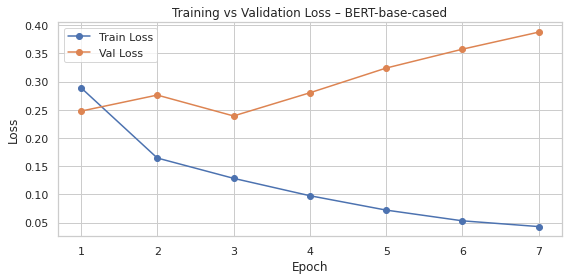

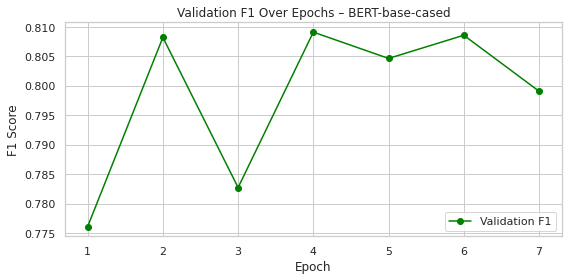


[2025-05-15_21-55-06] Validating...


[2025-05-15_21-55-07] Saved: val_metrics.json
[2025-05-15_21-55-07] Saved: val_report.txt

[2025-05-15_21-55-07] Testing...


[2025-05-15_21-55-08] Saved: test_metrics.json
[2025-05-15_21-55-08] Saved: test_report.txt
[2025-05-15_21-55-08] Saved: test_tag_report.json
[2025-05-15_21-55-08] Saved: test_class_metrics.json

Validation Report – BERT-base-cased
              precision    recall  f1-score   support

          AC     0.8171    0.9232    0.8669       508
          LF     0.6532    0.7941    0.7168       306

   micro avg     0.7526    0.8747    0.8091       814
   macro avg     0.7351    0.8587    0.7919       814
weighted avg     0.7555    0.8747    0.8105       814



**Accuracy**: `0.9176`

**Precision**: `0.7526`

...


Test Report – BERT-base-cased
              precision    recall  f1-score   support

          AC     0.8089    0.9660    0.8805       793
          LF     0.7229    0.8462    0.7797       481

   micro avg     0.7768    0.9207    0.8427      1274
   macro avg     0.7659    0.9061    0.8301      1274
weighted avg     0.7764    0.9207    0.8424      1274



**Accuracy**: `0.9376`

**Precision**: `0.7768`

**Recall**: `0.9207`

**F1**: `0.8427`

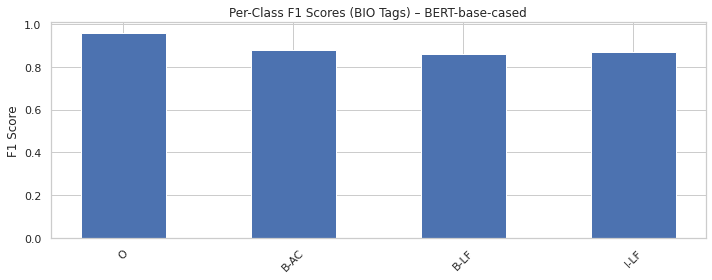

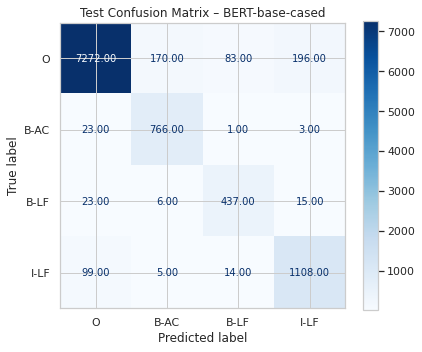


[Error Analysis] Top 5 misclassified tokens – BERT-base-cased:
Token:  'well'
Context: of the LCV is not well defined , but requires
True:   O
Pred:   B-LF

Token:  ','
Context: LCV is not well defined , but requires that L.
True:   O
Pred:   I-LF

Token:  'but'
Context: is not well defined , but requires that L. pneumophila
True:   O
Pred:   I-LF

Token:  'requires'
Context: not well defined , but requires that L. pneumophila injects
True:   O
Pred:   I-LF

Token:  '16'
Context: L 16 : Would contraceptive prevalence
True:   O
Pred:   B-AC



In [ ]:
# ===============================================================
# SECTION 2.3 - Transformer Fine-tuning
# Run 1 Setup 1 - BERT-base-cased on PLOD-CW-25
# ===============================================================
"""Self-contained, end-to-end fine-tuning script for BERT on PLOD-CW-25.

• Folder structure: `SECTION 2.3 – Transformer Fine-tuning/BERT/bert_base_cased/{plots, logs, model}`
• Uses HuggingFace Trainer API with robust fallbacks for legacy versions
• Logs training/validation/test metrics and error samples
• Plots confusion matrix and per-class F1 scores
"""


warnings.filterwarnings("ignore")

# Timestamp for logging
now = lambda: datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ---------------------------------------------------------------
# CLI Args & Reproducibility
# ---------------------------------------------------------------
parser = argparse.ArgumentParser()
parser.add_argument("--gpu", type=int, default=0)
parser.add_argument("--epochs", type=int, default=10)
parser.add_argument("--batch", type=int, default=8)
parser.add_argument("--lr", type=float, default=2e-5)
parser.add_argument("--fp16", action="store_true")
parser.add_argument("--eval_only", action="store_true")
args = parser.parse_args(args=[])

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------------
# Paths & Helpers
# ---------------------------------------------------------------
RUN_NAME = f"bert_base_cased"
BASE_DIR = Path(f"SECTION 2.3 – Transformer Fine-tuning/BERT/{RUN_NAME}")
PLOT_DIR, LOG_DIR, MODEL_DIR = [BASE_DIR / p for p in ("plots", "logs", "model")]
for d in [PLOT_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# Save helpers
def save_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(name, content):
    with open(LOG_DIR / name, "w", encoding="utf-8") as f:
        if isinstance(content, dict):
            json.dump(content, f, indent=2)
        else:
            f.write(content)
    print(f"[{now()}] Saved: {name}")


# ---------------------------------------------------------------
# Device Setup
# ---------------------------------------------------------------
use_cuda = args.gpu >= 0 and torch.cuda.is_available()
if use_cuda:
    torch.cuda.set_device(args.gpu)
    torch.backends.cudnn.benchmark = True  # Optimize for fixed input sizes
DEVICE = torch.device(f"cuda:{args.gpu}" if use_cuda else "cpu")
print(f"[{now()}] Device: {DEVICE}")

# Clear GPU cache
if use_cuda:
    torch.cuda.empty_cache()

# ---------------------------------------------------------------
# Dataset Prep & Label Analysis
# ---------------------------------------------------------------
try:
    assert {"train", "validation", "test"}.issubset(plod.keys()), "Missing splits!"
except Exception as e:
    raise ValueError(f"Dataset error: {e}")

LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}
IGNORE = -100

# Save training config
save_log("config.json", vars(args))


# Analyze label distribution
def get_label_stats(split):
    return {
        id2label[k]: v
        for k, v in Counter(tag for eg in plod[split] for tag in eg["ner_tags"]).items()
    }


label_stats = {k: get_label_stats(k) for k in ["train", "validation", "test"]}
save_log("label_distribution.json", label_stats)  # Log imbalance


# Verify token-label alignment
def tokenize(example: dict) -> dict:
    tokens, labels = example["tokens"], example["ner_tags"]
    assert len(tokens) == len(labels), "Token-label mismatch!"
    assert all(0 <= label < len(LABEL_NAMES) for label in labels), "Invalid label IDs"

    enc = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=256)
    word_ids = enc.word_ids()

    aligned, prev = [], None
    for w in word_ids:
        if w is None:
            aligned.append(IGNORE)
        elif w != prev:
            aligned.append(labels[w])
        else:
            aligned.append(IGNORE)
        prev = w

    enc["labels"] = aligned
    return enc


# ---------------------------------------------------------------
# Tokenizer + Model (FP16 Support)
# ---------------------------------------------------------------
CKPT = "bert-base-cased"
try:
    tokenizer = AutoTokenizer.from_pretrained(CKPT)
    config = AutoConfig.from_pretrained(
        CKPT, num_labels=len(LABEL_NAMES), id2label=id2label, label2id=label2id
    )
    if args.eval_only:
        print(f"[{now()}] Loading model from: {MODEL_DIR}")
        model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(DEVICE)
    else:
        model = AutoModelForTokenClassification.from_pretrained(CKPT, config=config).to(
            DEVICE
        )
except Exception as e:
    raise RuntimeError(f"Model loading failed: {e}")

# Enable FP16
if args.fp16 and use_cuda:
    model = model.half()

plod_enc = plod.map(tokenize, batched=False)
collator = DataCollatorForTokenClassification(tokenizer, pad_to_multiple_of=8)


# Metrics
def gather(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        t_seq, p_seq = [], []
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            t_seq.append(id2label[l])
            p_seq.append(id2label[p])
        y_t.append(t_seq)
        y_p.append(p_seq)
    return y_t, y_p


def flatten(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            y_t.append(l)
            y_p.append(p)
    return y_t, y_p


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = gather(preds, labels)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }


def to_python_types(obj):
    if isinstance(obj, dict):
        return {k: to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python_types(i) for i in obj]
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    else:
        return obj


# ---------------------------------------------------------------
# Training Arguments (Early Stopping)
# ---------------------------------------------------------------
try:
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        overwrite_output_dir=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        metric_for_best_model="f1",
        load_best_model_at_end=True,
        seed=SEED,
        report_to="none",
        fp16=args.fp16,
    )
except TypeError:
    print("\n[WARN] Older Transformers – using fallback Training Arguments\n")
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        do_train=True,
        do_eval=True,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        seed=SEED,
        fp16=args.fp16,
    )

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=plod_enc["train"],
    eval_dataset=plod_enc["validation"],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# ---------------------------------------------------------------
# Train + Loss Tracking
# ---------------------------------------------------------------
if not args.eval_only:
    print(f"\n[{now()}] Training...")
    train_results = trainer.train()

    # Check if early stopping was triggered
    if trainer.state.global_step < trainer.state.max_steps:
        print(
            f"[{now()}] Early stopping triggered at epoch {trainer.state.epoch:.0f} (step {trainer.state.global_step})"
        )
    else:
        print(f"[{now()}] Training completed full {args.epochs} epochs.")

    save_log("train_metrics.json", train_results.metrics)
    trainer.save_model(MODEL_DIR)
    tokenizer.save_pretrained(MODEL_DIR)

    history = trainer.state.log_history
    train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
    eval_loss = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
    eval_f1 = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

    # Loss Curve
    if train_loss and eval_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*train_loss), label="Train Loss", marker="o")
        plt.plot(*zip(*eval_loss), label="Val Loss", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Training vs Validation Loss – BERT-base-cased")
        save_plot("loss_curve")

    # F1 Curve
    if eval_f1:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*eval_f1), label="Validation F1", color="green", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.title("Validation F1 Over Epochs – BERT-base-cased")
        save_plot("f1_curve")

# ---------------------------------------------------------------
# Validation
# ---------------------------------------------------------------
print(f"\n[{now()}] Validating...")
val_metrics = trainer.evaluate()
val_preds = trainer.predict(plod_enc["validation"])
val_true, val_pred = gather(
    np.argmax(val_preds.predictions, axis=-1), val_preds.label_ids
)
val_report = classification_report(val_true, val_pred, digits=4, scheme=IOB2)

# Save validation metrics
val_metrics_custom = {
    "accuracy": accuracy_score(val_true, val_pred),
    "precision": precision_score(val_true, val_pred),
    "recall": recall_score(val_true, val_pred),
    "f1": f1_score(val_true, val_pred),
}

# [CLEANUP]
del val_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("val_metrics.json", val_metrics_custom)
    save_log("val_report.txt", val_report)
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Test
# ---------------------------------------------------------------
print(f"\n[{now()}] Testing...")
test_preds = trainer.predict(plod_enc["test"])

assert hasattr(test_preds, "predictions"), "No predictions found"
assert hasattr(test_preds, "label_ids"), "No label IDs found"

pred_labels = np.argmax(test_preds.predictions, axis=-1)
true_labels = test_preds.label_ids
test_true, test_pred = gather(pred_labels, true_labels)
flat_true, flat_pred = flatten(pred_labels, true_labels)
predictions_for_errors = np.argmax(
    test_preds.predictions, axis=-1
)  # Save for error analysis
test_report = classification_report(test_true, test_pred, digits=4, scheme=IOB2)

# Save test metrics
test_metrics = {
    "accuracy": accuracy_score(test_true, test_pred),
    "precision": precision_score(test_true, test_pred),
    "recall": recall_score(test_true, test_pred),
    "f1": f1_score(test_true, test_pred),
}

# Per-class metrics
tag_report = sk_report(
    flat_true,
    flat_pred,
    labels=list(range(len(LABEL_NAMES))),
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
)

class_metrics = {
    lbl: {
        "precision": tag_report[lbl]["precision"],
        "recall": tag_report[lbl]["recall"],
        "f1": tag_report[lbl]["f1-score"],
        "support": tag_report[lbl]["support"],
    }
    for lbl in LABEL_NAMES
}

# [CLEANUP]
del test_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("test_metrics.json", test_metrics)
    save_log("test_report.txt", test_report)
    save_log("test_tag_report.json", to_python_types(tag_report))
    save_log("test_class_metrics.json", to_python_types(class_metrics))
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Evaluation + Confusion Matrix + Error Samples
# ---------------------------------------------------------------

# Display validation results
print("\nValidation Report – BERT-base-cased")
print(val_report)
for k, v in val_metrics_custom.items():
    display(Markdown(f"**{k.title()}**: `{v:.4f}`"))

# Display test results
print("\nTest Report – BERT-base-cased")
print(test_report)
for k, v in test_metrics.items():
    display(Markdown(f"**{k.title()}**: `{v:.4f}`"))

# Plot class-wise F1
if class_metrics:
    plt.figure(figsize=(10, 4))
    f1_labels = list(class_metrics.keys())
    f1s = [m["f1"] for m in class_metrics.values()]
    plt.bar(f1_labels, f1s, width=0.5)
    plt.ylabel("F1 Score")
    plt.title("Per-Class F1 Scores (BIO Tags) – BERT-base-cased")
    plt.xticks(rotation=45)
    save_plot("class_f1_scores")
else:
    print("Warning: No class metrics to plot")

# Confusion Matrix
cm = confusion_matrix(flat_true, flat_pred, labels=list(id2label.keys()))
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format=".2f", ax=ax)
plt.title("Test Confusion Matrix – BERT-base-cased")
save_plot("cm_test")

# Error samples with context
print("\n[Error Analysis] Top 5 misclassified tokens – BERT-base-cased:")
shown = 0

for eg, lb_row, pr_row in zip(plod["test"], true_labels, predictions_for_errors):
    # iterate over *tokens* with their index
    for idx, (tok, l, p) in enumerate(zip(eg["tokens"], lb_row, pr_row)):
        if l == IGNORE:
            continue
        if l != p:  # mis-prediction
            ctx = " ".join(eg["tokens"][max(0, idx - 5) : idx + 5])
            print(
                f"Token:  '{tok}'\n"
                f"Context: {ctx}\n"
                f"True:   {id2label[l]}\n"
                f"Pred:   {id2label[p]}\n"
            )
            shown += 1
            if shown >= 5:
                break
    if shown >= 5:
        break

In [ ]:
# ===============================================================
# SECTION 2.3 - Transformer Fine-tuning
# Run 1 Setup 2 - BERT-base-cased with Focal Loss
# ===============================================================
"""End-to-end fine-tuning of BERT-base-cased on PLOD-CW-25 with Focal Loss.

• Implements a custom Trainer using Focal Loss to handle class imbalance
• Directory structure: `SECTION 2.3 – Transformer Fine-tuning/BERT/bert_base_cased_focal/{plots, logs, model}`
• Uses HuggingFace Trainer API with early stopping and compatibility fallbacks
• Saves training/validation/test metrics, classification reports, and confusion matrix
• Displays token-level error samples for manual inspection
"""


warnings.filterwarnings("ignore")

# Timestamp for logging
now = lambda: datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ---------------------------------------------------------------
# CLI Args & Reproducibility
# ---------------------------------------------------------------
parser = argparse.ArgumentParser()
parser.add_argument("--gpu", type=int, default=0)
parser.add_argument("--epochs", type=int, default=10)
parser.add_argument("--batch", type=int, default=8)
parser.add_argument("--lr", type=float, default=2e-5)
parser.add_argument("--gamma", type=float, default=2.0, help="Focal Loss gamma")
parser.add_argument("--fp16", action="store_true", help="Use mixed precision")
parser.add_argument("--warmup", type=float, default=0.1, help="Warmup ratio")
parser.add_argument(
    "--eval_only",
    action="store_true",
    help="Only load model and evaluate without training",
)
args = parser.parse_args(args=[])
assert args.gamma >= 0, "Gamma must be non-negative"

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------------
# Paths & Helpers
# ---------------------------------------------------------------
RUN_NAME = f"bert-base-cased_focal_loss"  # Unique run ID
BASE_DIR = Path(f"SECTION 2.3 – Transformer Fine-tuning/BERT/{RUN_NAME}")
PLOT_DIR, LOG_DIR, MODEL_DIR = [BASE_DIR / p for p in ("plots", "logs", "model")]
for d in (PLOT_DIR, LOG_DIR, MODEL_DIR):
    d.mkdir(parents=True, exist_ok=True)


# Save helpers
def save_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(name, content):
    with open(LOG_DIR / name, "w", encoding="utf-8") as f:
        if isinstance(content, dict):
            json.dump(content, f, indent=2)
        else:
            f.write(content)
    print(f"[{now()}] Saved: {name}")


# ---------------------------------------------------------------
# Device Setup
# ---------------------------------------------------------------
use_cuda = args.gpu >= 0 and torch.cuda.is_available()
if use_cuda:
    torch.cuda.set_device(args.gpu)
    torch.backends.cudnn.benchmark = True  # Optimize for fixed input sizes
DEVICE = torch.device(f"cuda:{args.gpu}" if use_cuda else "cpu")
print(f"[{now()}] Device: {DEVICE}")

# Clear GPU cache
if use_cuda:
    torch.cuda.empty_cache()

# ---------------------------------------------------------------
# Dataset Prep & Label Analysis
# ---------------------------------------------------------------
try:
    assert {"train", "validation", "test"}.issubset(plod.keys()), "Missing splits!"
except Exception as e:
    raise ValueError(f"Dataset error: {e}")

LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}
IGNORE = -100

# Save training config
save_log("config.json", vars(args))


# Analyze label distribution
def get_label_stats(split):
    return {
        id2label[k]: v
        for k, v in Counter(tag for eg in plod[split] for tag in eg["ner_tags"]).items()
    }


label_stats = {k: get_label_stats(k) for k in ["train", "validation", "test"]}
save_log("label_distribution.json", label_stats)  # Log imbalance


# Verify token-label alignment
def tokenize(example: dict) -> dict:
    tokens, labels = example["tokens"], example["ner_tags"]
    assert len(tokens) == len(labels), "Token-label mismatch!"
    assert all(0 <= label < len(LABEL_NAMES) for label in labels), "Invalid label IDs"

    enc = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=256)
    word_ids = enc.word_ids()

    aligned, prev = [], None
    for w in word_ids:
        if w is None:
            aligned.append(IGNORE)
        elif w != prev:
            aligned.append(labels[w])
        else:
            aligned.append(IGNORE)
        prev = w

    enc["labels"] = aligned
    return enc


# ---------------------------------------------------------------
# Tokenizer + Model (FP16 Support)
# ---------------------------------------------------------------
CKPT = "bert-base-cased"
try:
    tokenizer = AutoTokenizer.from_pretrained(CKPT)
    config = AutoConfig.from_pretrained(
        CKPT, num_labels=len(LABEL_NAMES), id2label=id2label, label2id=label2id
    )
    if args.eval_only:
        print(f"[{now()}] Loading model from: {MODEL_DIR}")
        model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(DEVICE)
    else:
        model = AutoModelForTokenClassification.from_pretrained(CKPT, config=config).to(
            DEVICE
        )
except Exception as e:
    raise RuntimeError(f"Model loading failed: {e}")

# Enable FP16
if args.fp16 and use_cuda:
    model = model.half()

plod_enc = plod.map(tokenize, batched=False)
collator = DataCollatorForTokenClassification(tokenizer, pad_to_multiple_of=8)


# ---------------------------------------------------------------
# Metrics & Helpers
# ---------------------------------------------------------------
def gather(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        t_seq, p_seq = [], []
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            t_seq.append(id2label[l])
            p_seq.append(id2label[p])
        y_t.append(t_seq)
        y_p.append(p_seq)
    return y_t, y_p


def flatten(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            y_t.append(l)
            y_p.append(p)
    return y_t, y_p


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = gather(preds, labels)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }


def to_python_types(obj):
    if isinstance(obj, dict):
        return {k: to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python_types(i) for i in obj]
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    else:
        return obj


# ---------------------------------------------------------------
# Focal Loss + Class Weighting
# ---------------------------------------------------------------
class FocalLoss(torch.nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: torch.Tensor | None = None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # Optional class weights
        self.ce_loss_fn = torch.nn.CrossEntropyLoss(
            ignore_index=IGNORE, reduction="none"
        )
        self._warned = False  # One-time warning flag
        self.per_class_losses = []  # Track per-class losses

    def forward(self, logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        # Flatten logits and labels
        logits_flat = logits.view(-1, logits.size(-1))
        labels_flat = labels.view(-1)

        # Filter valid labels
        valid = (
            (labels_flat != IGNORE)
            & (labels_flat >= 0)
            & (labels_flat < logits.size(-1))
        )
        if not valid.any():
            return torch.tensor(0.0, device=logits.device, requires_grad=True)

        logits_valid = logits_flat[valid]
        labels_valid = labels_flat[valid]

        # One-time warning for label bounds
        if not self._warned and labels_valid.max() >= logits.size(-1):
            warnings.warn(
                f"[WARN] Invalid label id detected: {labels_valid.max()} ≥ {logits.size(-1)}"
            )
            self._warned = True

        # Cross-entropy loss
        ce_loss = self.ce_loss_fn(logits_valid, labels_valid)

        # Focal modulation
        pt = torch.exp(-ce_loss).clamp(min=1e-7, max=1 - 1e-7)  # Stability
        focal_term = (1 - pt) ** self.gamma

        # Apply alpha weights if provided
        if self.alpha is not None:
            alpha_factor = self.alpha[labels_valid.to(self.alpha.device)]
            ce_loss = alpha_factor * ce_loss

        # Track per-class average losses
        per_class_loss = torch.zeros(len(LABEL_NAMES), device=logits.device)
        for i in range(len(LABEL_NAMES)):
            mask = labels_valid == i
            if mask.any():
                per_class_loss[i] = (
                    (focal_term[mask] * ce_loss[mask]).mean()
                    if mask.any()
                    else float("nan")
                )

        # Append per-class loss (1 value per class, per step)
        self.per_class_losses.append(per_class_loss.detach().cpu().tolist())

        return (focal_term * ce_loss).mean()


# Auto-calculate smoothed class weights
class_counts = torch.tensor(
    [label_stats["train"].get(label, 1) for label in LABEL_NAMES], dtype=torch.float
)
log_smooth = torch.log(class_counts + 1.718)
inv_weights = 1.0 / log_smooth
inv_weights[0] = 1.0  # Do not boost 'O'

# Normalize weights to sum to 1
class_weights = inv_weights / inv_weights.sum()
focal_loss = FocalLoss(gamma=args.gamma, alpha=class_weights.to(DEVICE))


# ---------------------------------------------------------------
# Custom Trainer + Focal Loss
# ---------------------------------------------------------------
class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        with torch.cuda.amp.autocast(enabled=self.args.fp16):
            outputs = model(**inputs)
            logits = outputs.logits
            loss = focal_loss(logits.view(-1, len(LABEL_NAMES)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


# ---------------------------------------------------------------
# Training Arguments + Trainer (Early Stopping)
# ---------------------------------------------------------------
try:
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        overwrite_output_dir=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        metric_for_best_model="f1",
        load_best_model_at_end=True,
        seed=SEED,
        report_to="none",
        fp16=args.fp16,
    )
except TypeError:
    print("\n[WARN] Older Transformers – using fallback Training Arguments\n")
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        do_train=True,
        do_eval=True,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        seed=SEED,
        fp16=args.fp16,
    )

trainer = FocalTrainer(
    model=model,
    args=train_args,
    train_dataset=plod_enc["train"],
    eval_dataset=plod_enc["validation"],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# ---------------------------------------------------------------
# Train + Loss Tracking
# ---------------------------------------------------------------
if not args.eval_only:
    print(f"\n[{now()}] Training...")
    train_results = trainer.train()

    # Check if early stopping was triggered
    if trainer.state.global_step < trainer.state.max_steps:
        print(
            f"[{now()}] Early stopping triggered at epoch {trainer.state.epoch:.0f} (step {trainer.state.global_step})"
        )
    else:
        print(f"[{now()}] Training completed full {args.epochs} epochs.")

    save_log("train_metrics.json", train_results.metrics)
    trainer.save_model(MODEL_DIR)

    history = trainer.state.log_history
    train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
    eval_loss = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
    eval_f1 = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

    # Loss Curve
    if train_loss and eval_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*train_loss), label="Train Loss", marker="o")
        plt.plot(*zip(*eval_loss), label="Val Loss", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Training vs Validation Loss – BERT-base-cased (Focal Loss)")
        save_plot("loss_curve")

    # F1 Curve
    if eval_f1:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*eval_f1), label="Validation F1", color="green", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.title("Validation F1 Over Epochs – BERT-base-cased (Focal Loss)")
        save_plot("f1_curve")

    # Per-Class Focal Loss Curve
    if hasattr(focal_loss, "per_class_losses") and focal_loss.per_class_losses:
        plt.figure(figsize=(10, 4))
        losses = list(zip(*focal_loss.per_class_losses))  # Transpose
        for i, lbl in enumerate(LABEL_NAMES):
            plt.plot(losses[i], label=lbl)
        plt.xlabel("Step")
        plt.ylabel("Focal Loss")
        plt.title("Per-Class Focal Loss over Steps – BERT-base-cased")
        plt.legend(loc="upper right", ncol=2, fontsize="small")
        plt.grid(True)
        save_plot("focal_loss_per_class")

# ---------------------------------------------------------------
# Validation
# ---------------------------------------------------------------
print(f"\n[{now()}] Validating...")
val_metrics = trainer.evaluate()
val_preds = trainer.predict(plod_enc["validation"])
val_true, val_pred = gather(
    np.argmax(val_preds.predictions, axis=-1), val_preds.label_ids
)
val_report = classification_report(val_true, val_pred, digits=4, scheme=IOB2)

# Save validation metrics
val_metrics_custom = {
    "accuracy": accuracy_score(val_true, val_pred),
    "precision": precision_score(val_true, val_pred),
    "recall": recall_score(val_true, val_pred),
    "f1": f1_score(val_true, val_pred),
}

# [CLEANUP]
del val_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("val_metrics.json", val_metrics_custom)
    save_log("val_report.txt", val_report)
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Test
# ---------------------------------------------------------------
print(f"\n[{now()}] Testing...")
test_preds = trainer.predict(plod_enc["test"])

assert hasattr(test_preds, "predictions"), "No predictions found"
assert hasattr(test_preds, "label_ids"), "No label IDs found"

pred_labels = np.argmax(test_preds.predictions, axis=-1)
true_labels = test_preds.label_ids
test_true, test_pred = gather(pred_labels, true_labels)
flat_true, flat_pred = flatten(pred_labels, true_labels)
predictions_for_errors = np.argmax(
    test_preds.predictions, axis=-1
)  # Save for error analysis
test_report = classification_report(test_true, test_pred, digits=4, scheme=IOB2)

# # Save test metrics
test_metrics = {
    "accuracy": accuracy_score(test_true, test_pred),
    "precision": precision_score(test_true, test_pred),
    "recall": recall_score(test_true, test_pred),
    "f1": f1_score(test_true, test_pred),
}

# Per-class metrics
tag_report = sk_report(
    flat_true,
    flat_pred,
    labels=list(range(len(LABEL_NAMES))),
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
)

class_metrics = {
    lbl: {
        "precision": tag_report[lbl]["precision"],
        "recall": tag_report[lbl]["recall"],
        "f1": tag_report[lbl]["f1-score"],
        "support": tag_report[lbl]["support"],
    }
    for lbl in LABEL_NAMES
}

# [CLEANUP]
del test_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("test_metrics.json", test_metrics)
    save_log("test_report.txt", test_report)
    save_log("test_tag_report.json", to_python_types(tag_report))
    save_log("test_class_metrics.json", to_python_types(class_metrics))
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Evaluation + Confusion Matrix + Error Samples
# ---------------------------------------------------------------

# Display validation results
print("\nValidation Report – BERT-base-cased (Focal Loss)")
print(val_report)
for k, v in val_metrics_custom.items():
    display(Markdown(f"**{k.title()}**: `{v:.4f}`"))

# Display test results
print("\nTest Report – BERT-base-cased (Focal Loss)")
print(test_report)
for k, v in test_metrics.items():
    display(Markdown(f"**{k.title()}**: `{v:.4f}`"))

# Plot class-wise F1
if class_metrics:
    plt.figure(figsize=(10, 4))
    f1_labels = list(class_metrics.keys())
    f1s = [m["f1"] for m in class_metrics.values()]
    plt.bar(f1_labels, f1s, width=0.5)
    plt.ylabel("F1 Score")
    plt.title("Per-Class F1 Scores (BIO Tags) – BERT-base-cased (Focal Loss)")
    plt.xticks(rotation=45)
    save_plot("class_f1_scores")
else:
    print("Warning: No class metrics to plot")

# Confusion Matrix
cm = confusion_matrix(flat_true, flat_pred, labels=list(id2label.keys()))
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format=".2f", ax=ax)
plt.title("Test Confusion Matrix – BERT-base-cased (Focal Loss)")
save_plot("cm_test")

# Error samples with context
print("\n[Error Analysis] Top 5 misclassified tokens – BERT-base-cased (Focal Loss):")
shown = 0

for eg, lb_row, pr_row in zip(plod["test"], true_labels, predictions_for_errors):
    # iterate over *tokens* with their index
    for idx, (tok, l, p) in enumerate(zip(eg["tokens"], lb_row, pr_row)):
        if l == IGNORE:
            continue
        if l != p:  # mis-prediction
            ctx = " ".join(eg["tokens"][max(0, idx - 5) : idx + 5])
            print(
                f"Token:  '{tok}'\n"
                f"Context: {ctx}\n"
                f"True:   {id2label[l]}\n"
                f"Pred:   {id2label[p]}\n"
            )
            shown += 1
            if shown >= 5:
                break
    if shown >= 5:
        break

## 2.3.2 Transformer Fine‑tuning(Bio_ClinicalBERT)

[2025-05-15_21-57-00] Device: cuda:0
[2025-05-15_21-57-00] Saved: config.json
[2025-05-15_21-57-01] Saved: label_distribution.json


Some weights of BertForTokenClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



[2025-05-15_21-57-02] Training...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.312800,0.263741,0.904897,0.750000,0.799754,0.774078
2,0.168400,0.286684,0.907229,0.746269,0.859951,0.799087
3,0.124400,0.258732,0.909560,0.754247,0.818182,0.784915
4,0.089700,0.326853,0.906562,0.749443,0.826781,0.786215
5,0.065400,0.379102,0.907229,0.753986,0.813268,0.782506


[2025-05-15_21-59-19] Early stopping triggered at epoch 5 (step 1250)
[2025-05-15_21-59-19] Saved: train_metrics.json


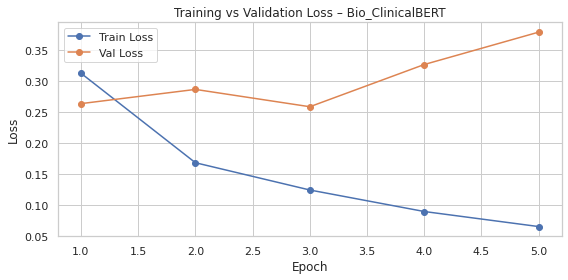

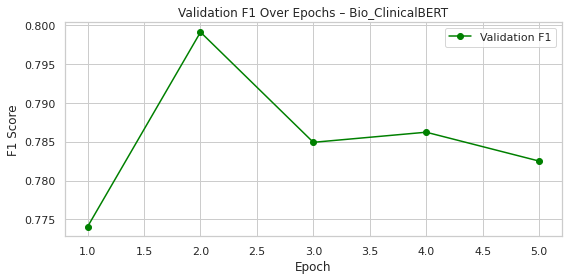


[2025-05-15_21-59-20] Validating...


[2025-05-15_21-59-21] Saved: val_metrics.json
[2025-05-15_21-59-21] Saved: val_report.txt

[2025-05-15_21-59-21] Testing...


[2025-05-15_21-59-22] Saved: test_metrics.json
[2025-05-15_21-59-22] Saved: test_report.txt
[2025-05-15_21-59-22] Saved: test_tag_report.json
[2025-05-15_21-59-22] Saved: test_class_metrics.json

Validation Report – Bio_ClinicalBERT
              precision    recall  f1-score   support

          AC     0.8169    0.8957    0.8545       508
          LF     0.6430    0.8007    0.7132       306

   micro avg     0.7463    0.8600    0.7991       814
   macro avg     0.7300    0.8482    0.7839       814
weighted avg     0.7515    0.8600    0.8014       814



**Accuracy**: `0.9072`

**Precision**: `0.7463`

...


Test Report – Bio_ClinicalBERT
              precision    recall  f1-score   support

          AC     0.8047    0.9508    0.8717       793
          LF     0.6943    0.8545    0.7661       481

   micro avg     0.7619    0.9144    0.8313      1274
   macro avg     0.7495    0.9026    0.8189      1274
weighted avg     0.7630    0.9144    0.8318      1274



**Accuracy**: `0.9326`

**Precision**: `0.7619`

**Recall**: `0.9144`

**F1**: `0.8313`

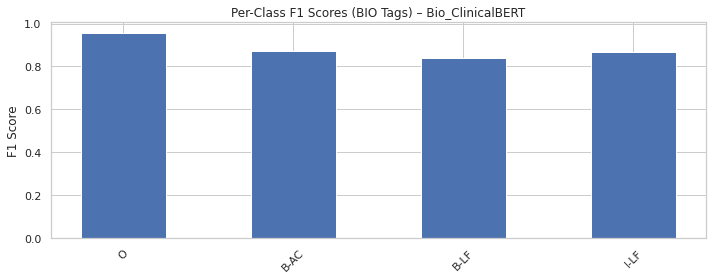

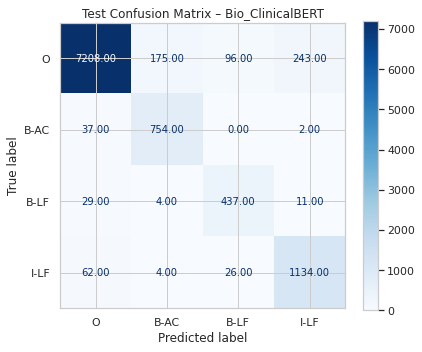


[Error Analysis] Top 5 misclassified tokens – Bio_ClinicalBERT:
Token:  'well'
Context: of the LCV is not well defined , but requires
True:   O
Pred:   B-LF

Token:  'but'
Context: is not well defined , but requires that L. pneumophila
True:   O
Pred:   I-LF

Token:  'requires'
Context: not well defined , but requires that L. pneumophila injects
True:   O
Pred:   I-LF

Token:  'that'
Context: well defined , but requires that L. pneumophila injects proteins
True:   O
Pred:   I-LF

Token:  'be'
Context: modern CPR ( mCPR ) be more appropriate ?
True:   O
Pred:   B-LF



In [ ]:
# ===============================================================
# SECTION 2.3 - Transformer Fine-tuning
# Run 2 Setup 1 - Bio_ClinicalBERT on PLOD-CW-25
# ===============================================================
"""Self-contained, end-to-end fine-tuning script for Bio_ClinicalBERT on PLOD-CW-25.

• Folder structure: SECTION 2.3 – Transformer Fine-tuning/Bio_ClinicalBERT/bio_clinicalbert/{plots, logs, model}
• Uses HuggingFace Trainer API with fallback support
• Logs training/validation/test metrics and error samples
• Plots confusion matrix and per-class F1 scores
"""

warnings.filterwarnings("ignore")

# Timestamp for logging
now = lambda: datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ---------------------------------------------------------------
# CLI Args & Reproducibility
# ---------------------------------------------------------------
parser = argparse.ArgumentParser()
parser.add_argument("--gpu", type=int, default=0)
parser.add_argument("--epochs", type=int, default=10)
parser.add_argument("--batch", type=int, default=8)
parser.add_argument("--lr", type=float, default=2e-5)
parser.add_argument("--fp16", action="store_true")
parser.add_argument("--eval_only", action="store_true")
args = parser.parse_args(args=[])

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------------
# Paths & Helpers
# ---------------------------------------------------------------
RUN_NAME = f"bio_clinicalbert"
BASE_DIR = Path(f"SECTION 2.3 – Transformer Fine-tuning/Bio_ClinicalBERT/{RUN_NAME}")
PLOT_DIR, LOG_DIR, MODEL_DIR = [BASE_DIR / p for p in ("plots", "logs", "model")]
for d in [PLOT_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# Save helpers
def save_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(name, content):
    with open(LOG_DIR / name, "w", encoding="utf-8") as f:
        if isinstance(content, dict):
            json.dump(content, f, indent=2)
        else:
            f.write(content)
    print(f"[{now()}] Saved: {name}")


# ---------------------------------------------------------------
# Device Setup
# ---------------------------------------------------------------
use_cuda = args.gpu >= 0 and torch.cuda.is_available()
if use_cuda:
    torch.cuda.set_device(args.gpu)
    torch.backends.cudnn.benchmark = True  # Optimize for fixed input sizes
DEVICE = torch.device(f"cuda:{args.gpu}" if use_cuda else "cpu")
print(f"[{now()}] Device: {DEVICE}")

# Clear GPU cache
if use_cuda:
    torch.cuda.empty_cache()

# ---------------------------------------------------------------
# Dataset Prep & Label Analysis
# ---------------------------------------------------------------
try:
    assert {"train", "validation", "test"}.issubset(plod.keys()), "Missing splits!"
except Exception as e:
    raise ValueError(f"Dataset error: {e}")

LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}
IGNORE = -100

# Save training config
save_log("config.json", vars(args))


# Analyze label distribution
def get_label_stats(split):
    return {
        id2label[k]: v
        for k, v in Counter(tag for eg in plod[split] for tag in eg["ner_tags"]).items()
    }


label_stats = {k: get_label_stats(k) for k in ["train", "validation", "test"]}
save_log("label_distribution.json", label_stats)  # Log imbalance


# Verify token-label alignment
def tokenize(example: dict) -> dict:
    tokens, labels = example["tokens"], example["ner_tags"]
    assert len(tokens) == len(labels), "Token-label mismatch!"
    assert all(0 <= label < len(LABEL_NAMES) for label in labels), "Invalid label IDs"

    enc = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=256)
    word_ids = enc.word_ids()

    aligned, prev = [], None
    for w in word_ids:
        if w is None:
            aligned.append(IGNORE)
        elif w != prev:
            aligned.append(labels[w])
        else:
            aligned.append(IGNORE)
        prev = w

    enc["labels"] = aligned
    return enc


# ---------------------------------------------------------------
# Tokenizer + Model (FP16 Support)
# ---------------------------------------------------------------
CKPT = "emilyalsentzer/Bio_ClinicalBERT"
try:
    tokenizer = AutoTokenizer.from_pretrained(CKPT)
    config = AutoConfig.from_pretrained(
        CKPT, num_labels=len(LABEL_NAMES), id2label=id2label, label2id=label2id
    )
    if args.eval_only:
        print(f"[{now()}] Loading model from: {MODEL_DIR}")
        model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(DEVICE)
    else:
        model = AutoModelForTokenClassification.from_pretrained(CKPT, config=config).to(
            DEVICE
        )
except Exception as e:
    raise RuntimeError(f"Model loading failed: {e}")

# Enable FP16
if args.fp16 and use_cuda:
    model = model.half()

plod_enc = plod.map(tokenize, batched=False)
collator = DataCollatorForTokenClassification(tokenizer, pad_to_multiple_of=8)


# Metrics
def gather(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        t_seq, p_seq = [], []
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            t_seq.append(id2label[l])
            p_seq.append(id2label[p])
        y_t.append(t_seq)
        y_p.append(p_seq)
    return y_t, y_p


def flatten(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            y_t.append(l)
            y_p.append(p)
    return y_t, y_p


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = gather(preds, labels)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }


def to_python_types(obj):
    if isinstance(obj, dict):
        return {k: to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python_types(i) for i in obj]
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    else:
        return obj


# ---------------------------------------------------------------
# Training Arguments (Early Stopping)
# ---------------------------------------------------------------
try:
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        overwrite_output_dir=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        metric_for_best_model="f1",
        load_best_model_at_end=True,
        seed=SEED,
        report_to="none",
        fp16=args.fp16,
    )
except TypeError:
    print("\n[WARN] Older Transformers – using fallback Training Arguments\n")
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        do_train=True,
        do_eval=True,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        seed=SEED,
        fp16=args.fp16,
    )

trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=plod_enc["train"],
    eval_dataset=plod_enc["validation"],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# ---------------------------------------------------------------
# Train + Loss Tracking
# ---------------------------------------------------------------
if not args.eval_only:
    print(f"\n[{now()}] Training...")
    train_results = trainer.train()

    # Check if early stopping was triggered
    if trainer.state.global_step < trainer.state.max_steps:
        print(
            f"[{now()}] Early stopping triggered at epoch {trainer.state.epoch:.0f} (step {trainer.state.global_step})"
        )
    else:
        print(f"[{now()}] Training completed full {args.epochs} epochs.")

    save_log("train_metrics.json", train_results.metrics)
    trainer.save_model(MODEL_DIR)
    tokenizer.save_pretrained(MODEL_DIR)

    history = trainer.state.log_history
    train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
    eval_loss = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
    eval_f1 = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

    # Loss Curve
    if train_loss and eval_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*train_loss), label="Train Loss", marker="o")
        plt.plot(*zip(*eval_loss), label="Val Loss", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title("Training vs Validation Loss – Bio_ClinicalBERT")
        save_plot("loss_curve")

    # F1 Curve
    if eval_f1:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*eval_f1), label="Validation F1", color="green", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.title("Validation F1 Over Epochs – Bio_ClinicalBERT")
        save_plot("f1_curve")

# ---------------------------------------------------------------
# Validation
# ---------------------------------------------------------------
print(f"\n[{now()}] Validating...")
val_metrics = trainer.evaluate()
val_preds = trainer.predict(plod_enc["validation"])
val_true, val_pred = gather(
    np.argmax(val_preds.predictions, axis=-1), val_preds.label_ids
)
val_report = classification_report(val_true, val_pred, digits=4, scheme=IOB2)

# Save val metrics
val_metrics_custom = {
    "accuracy": accuracy_score(val_true, val_pred),
    "precision": precision_score(val_true, val_pred),
    "recall": recall_score(val_true, val_pred),
    "f1": f1_score(val_true, val_pred),
}

# [CLEANUP]
del val_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("val_metrics.json", val_metrics_custom)
    save_log("val_report.txt", val_report)
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Test
# ---------------------------------------------------------------
print(f"\n[{now()}] Testing...")
test_preds = trainer.predict(plod_enc["test"])

assert hasattr(test_preds, "predictions"), "No predictions found"
assert hasattr(test_preds, "label_ids"), "No label IDs found"

pred_labels = np.argmax(test_preds.predictions, axis=-1)
true_labels = test_preds.label_ids
test_true, test_pred = gather(pred_labels, true_labels)
flat_true, flat_pred = flatten(pred_labels, true_labels)
predictions_for_errors = np.argmax(
    test_preds.predictions, axis=-1
)  # Save for error analysis
test_report = classification_report(test_true, test_pred, digits=4, scheme=IOB2)

# Save test metrics
test_metrics = {
    "accuracy": accuracy_score(test_true, test_pred),
    "precision": precision_score(test_true, test_pred),
    "recall": recall_score(test_true, test_pred),
    "f1": f1_score(test_true, test_pred),
}

# Per-class metrics
tag_report = sk_report(
    flat_true,
    flat_pred,
    labels=list(range(len(LABEL_NAMES))),
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
)

class_metrics = {
    lbl: {
        "precision": tag_report[lbl]["precision"],
        "recall": tag_report[lbl]["recall"],
        "f1": tag_report[lbl]["f1-score"],
        "support": tag_report[lbl]["support"],
    }
    for lbl in LABEL_NAMES
}

# [CLEANUP]
del test_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("test_metrics.json", test_metrics)
    save_log("test_report.txt", test_report)
    save_log("test_tag_report.json", to_python_types(tag_report))
    save_log("test_class_metrics.json", to_python_types(class_metrics))
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Evaluation + Confusion Matrix + Error Samples
# ---------------------------------------------------------------

# Display validation results
print("\nValidation Report – Bio_ClinicalBERT")
print(val_report)
for k, v in val_metrics_custom.items():
    display(Markdown(f"**{k.title()}**: `{v:.4f}`"))

# Display test results
print("\nTest Report – Bio_ClinicalBERT")
print(test_report)
for k, v in test_metrics.items():
    display(Markdown(f"**{k.title()}**: `{v:.4f}`"))

# Plot class-wise F1
if class_metrics:
    plt.figure(figsize=(10, 4))
    f1_labels = list(class_metrics.keys())
    f1s = [m["f1"] for m in class_metrics.values()]
    plt.bar(f1_labels, f1s, width=0.5)
    plt.ylabel("F1 Score")
    plt.title("Per-Class F1 Scores (BIO Tags) – Bio_ClinicalBERT")
    plt.xticks(rotation=45)
    save_plot("class_f1_scores")
else:
    print("Warning: No class metrics to plot")

# Confusion Matrix
cm = confusion_matrix(flat_true, flat_pred, labels=list(id2label.keys()))
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format=".2f", ax=ax)
plt.title("Test Confusion Matrix – Bio_ClinicalBERT")
save_plot("cm_test")

# Error samples with context
print("\n[Error Analysis] Top 5 misclassified tokens – Bio_ClinicalBERT:")
shown = 0

for eg, lb_row, pr_row in zip(plod["test"], true_labels, predictions_for_errors):
    # iterate over tokens with their index
    for idx, (tok, l, p) in enumerate(zip(eg["tokens"], lb_row, pr_row)):
        if l == IGNORE:
            continue
        if l != p:  # mis-prediction
            ctx = " ".join(eg["tokens"][max(0, idx - 5) : idx + 5])
            print(
                f"Token:  '{tok}'\n"
                f"Context: {ctx}\n"
                f"True:   {id2label[l]}\n"
                f"Pred:   {id2label[p]}\n"
            )
            shown += 1
            if shown >= 5:
                break
    if shown >= 5:
        break

In [ ]:
# ===============================================================
# SECTION 2.3 - Transformer Fine-tuning
# Run 2 Setup 2 - Bio_ClinicalBERT with Focal Loss + Cosine Scheduler
# ===============================================================

"""Fine-tuning Bio_ClinicalBERT on PLOD-CW-25 using Focal Loss and CosineAnnealingWarmRestarts.

• Loss Function: Focal Loss (γ = 2.0) with class weights
• Optimizer: AdamW
• Scheduler: CosineAnnealingWarmRestarts (warm restarts every T_0 epochs)
• Model: emilyalsentzer/Bio_ClinicalBERT
• Saves training/validation/test metrics, per-class F1, confusion matrix, and error samples
"""

warnings.filterwarnings("ignore")

# Timestamp for logging
now = lambda: datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# ---------------------------------------------------------------
# CLI Args & Reproducibility
# ---------------------------------------------------------------
parser = argparse.ArgumentParser()
parser.add_argument("--gpu", type=int, default=0)
parser.add_argument("--epochs", type=int, default=10)
parser.add_argument("--batch", type=int, default=8)
parser.add_argument("--lr", type=float, default=2e-5)
parser.add_argument("--gamma", type=float, default=2.0, help="Focal Loss gamma")
parser.add_argument("--fp16", action="store_true", help="Use mixed precision")
parser.add_argument(
    "--t0", type=int, default=5, help="T_0 for CosineAnnealingWarmRestarts"
)
parser.add_argument(
    "--eval_only",
    action="store_true",
    help="Only load model and evaluate without training",
)
args = parser.parse_args(args=[])
assert args.gamma >= 0, "Gamma must be non-negative"

# Reproducibility
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------------------------------------------
# Paths & Helpers
# ---------------------------------------------------------------
RUN_NAME = f"bio_clinicalbert_focal_cosine"  # Unique run ID
BASE_DIR = Path(f"SECTION 2.3 – Transformer Fine-tuning/Bio_ClinicalBERT/{RUN_NAME}")
PLOT_DIR, LOG_DIR, MODEL_DIR = [BASE_DIR / p for p in ("plots", "logs", "model")]
for d in [PLOT_DIR, LOG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)


# Save helpers
def save_plot(name):
    plt.tight_layout()
    plt.savefig(PLOT_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()


def save_log(name, content):
    with open(LOG_DIR / name, "w", encoding="utf-8") as f:
        if isinstance(content, dict):
            json.dump(content, f, indent=2)
        else:
            f.write(content)
    print(f"[{now()}] Saved: {name}")


# ---------------------------------------------------------------
# Device Setup
# ---------------------------------------------------------------
use_cuda = args.gpu >= 0 and torch.cuda.is_available()
if use_cuda:
    torch.cuda.set_device(args.gpu)
    torch.backends.cudnn.benchmark = True  # Optimize for fixed input sizes
DEVICE = torch.device(f"cuda:{args.gpu}" if use_cuda else "cpu")
print(f"[{now()}] Device: {DEVICE}")

# Clear GPU cache
if use_cuda:
    torch.cuda.empty_cache()

# ---------------------------------------------------------------
# Dataset Prep & Label Analysis
# ---------------------------------------------------------------
try:
    assert {"train", "validation", "test"}.issubset(plod.keys()), "Missing splits!"
except Exception as e:
    raise ValueError(f"Dataset error: {e}")

LABEL_NAMES = plod["train"].features["ner_tags"].feature.names
label2id = {l: i for i, l in enumerate(LABEL_NAMES)}
id2label = {i: l for l, i in label2id.items()}
IGNORE = -100

# Save training config
save_log("config.json", vars(args))


# Analyze label distribution
def get_label_stats(split):
    return {
        id2label[k]: v
        for k, v in Counter(tag for eg in plod[split] for tag in eg["ner_tags"]).items()
    }


label_stats = {k: get_label_stats(k) for k in ["train", "validation", "test"]}
save_log("label_distribution.json", label_stats)  # Log imbalance


# Verify token-label alignment
def tokenize(example: dict) -> dict:
    tokens, labels = example["tokens"], example["ner_tags"]
    assert len(tokens) == len(labels), "Token-label mismatch!"
    assert all(0 <= label < len(LABEL_NAMES) for label in labels), "Invalid label IDs"

    enc = tokenizer(tokens, is_split_into_words=True, truncation=True, max_length=256)
    word_ids = enc.word_ids()

    aligned, prev = [], None
    for w in word_ids:
        if w is None:
            aligned.append(IGNORE)
        elif w != prev:
            aligned.append(labels[w])
        else:
            aligned.append(IGNORE)
        prev = w

    enc["labels"] = aligned
    return enc


# ---------------------------------------------------------------
# Tokenizer + Model (FP16 Support)
# ---------------------------------------------------------------
CKPT = "emilyalsentzer/Bio_ClinicalBERT"
try:
    tokenizer = AutoTokenizer.from_pretrained(CKPT)
    config = AutoConfig.from_pretrained(
        CKPT, num_labels=len(LABEL_NAMES), id2label=id2label, label2id=label2id
    )
    if args.eval_only:
        print(f"[{now()}] Loading model from: {MODEL_DIR}")
        model = AutoModelForTokenClassification.from_pretrained(MODEL_DIR).to(DEVICE)
    else:
        model = AutoModelForTokenClassification.from_pretrained(CKPT, config=config).to(
            DEVICE
        )
except Exception as e:
    raise RuntimeError(f"Model loading failed: {e}")

# Enable FP16
if args.fp16 and use_cuda:
    model = model.half()

plod_enc = plod.map(tokenize, batched=False)
collator = DataCollatorForTokenClassification(tokenizer, pad_to_multiple_of=8)


# ---------------------------------------------------------------
# Metrics & Helpers
# ---------------------------------------------------------------
def gather(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        t_seq, p_seq = [], []
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            t_seq.append(id2label[l])
            p_seq.append(id2label[p])
        y_t.append(t_seq)
        y_p.append(p_seq)
    return y_t, y_p


def flatten(preds, labels):
    y_t, y_p = [], []
    for pr, lb in zip(preds, labels):
        for p, l in zip(pr, lb):
            if l == IGNORE:
                continue
            y_t.append(l)
            y_p.append(p)
    return y_t, y_p


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    y_true, y_pred = gather(preds, labels)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }


def to_python_types(obj):
    if isinstance(obj, dict):
        return {k: to_python_types(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python_types(i) for i in obj]
    elif isinstance(obj, (np.integer, np.int64)):
        return int(obj)
    elif isinstance(obj, (np.floating, np.float64)):
        return float(obj)
    else:
        return obj


# ---------------------------------------------------------------
# Focal Loss + Class Weighting
# ---------------------------------------------------------------
class FocalLoss(torch.nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: torch.Tensor | None = None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha  # Optional class weights
        self.ce_loss_fn = torch.nn.CrossEntropyLoss(
            ignore_index=IGNORE, reduction="none"
        )
        self._warned = False  # One-time warning flag
        self.per_class_losses = []  # Track per-class losses

    def forward(self, logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        # Flatten logits and labels
        logits_flat = logits.view(-1, logits.size(-1))
        labels_flat = labels.view(-1)

        # Filter valid labels
        valid = (
            (labels_flat != IGNORE)
            & (labels_flat >= 0)
            & (labels_flat < logits.size(-1))
        )
        if not valid.any():
            return torch.tensor(0.0, device=logits.device, requires_grad=True)

        logits_valid = logits_flat[valid]
        labels_valid = labels_flat[valid]

        # One-time warning for label bounds
        if not self._warned and labels_valid.max() >= logits.size(-1):
            warnings.warn(
                f"[WARN] Invalid label id detected: {labels_valid.max()} ≥ {logits.size(-1)}"
            )
            self._warned = True

        # Cross-entropy loss
        ce_loss = self.ce_loss_fn(logits_valid, labels_valid)

        # Focal modulation
        pt = torch.exp(-ce_loss).clamp(min=1e-7, max=1 - 1e-7)  # Stability
        focal_term = (1 - pt) ** self.gamma

        # Apply alpha weights if provided
        if self.alpha is not None:
            alpha_factor = self.alpha[labels_valid.to(self.alpha.device)]
            ce_loss = alpha_factor * ce_loss

        # Track per-class average losses
        per_class_loss = torch.zeros(len(LABEL_NAMES), device=logits.device)
        for i in range(len(LABEL_NAMES)):
            mask = labels_valid == i
            if mask.any():
                per_class_loss[i] = (
                    (focal_term[mask] * ce_loss[mask]).mean()
                    if mask.any()
                    else float("nan")
                )

        # Append per-class loss (1 value per class, per step)
        self.per_class_losses.append(per_class_loss.detach().cpu().tolist())

        return (focal_term * ce_loss).mean()


# Auto-calculate smoothed class weights
class_counts = torch.tensor(
    [label_stats["train"].get(label, 1) for label in LABEL_NAMES], dtype=torch.float
)
log_smooth = torch.log(class_counts + 1.718)
inv_weights = 1.0 / log_smooth
inv_weights[0] = 1.0  # Do not boost 'O'

# Normalize weights to sum to 1
class_weights = inv_weights / inv_weights.sum()
focal_loss = FocalLoss(gamma=args.gamma, alpha=class_weights.to(DEVICE))


# ---------------------------------------------------------------
# Custom Trainer + Focal Loss
# ---------------------------------------------------------------
class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        with torch.cuda.amp.autocast(enabled=self.args.fp16):
            outputs = model(**inputs)
            logits = outputs.logits
            loss = focal_loss(logits.view(-1, len(LABEL_NAMES)), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

    def create_optimizer_and_scheduler(self, num_training_steps):
        self.optimizer = AdamW(self.model.parameters(), lr=args.lr, weight_decay=0.01)
        self.lr_scheduler = CosineAnnealingWarmRestarts(
            self.optimizer, T_0=args.t0, eta_min=1e-7
        )


# ---------------------------------------------------------------
# Training Arguments + Trainer (Early Stopping)
# ---------------------------------------------------------------
try:
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        overwrite_output_dir=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        save_total_limit=2,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        metric_for_best_model="f1",
        load_best_model_at_end=True,
        seed=SEED,
        report_to="none",
        fp16=args.fp16,
    )
except TypeError:
    print("\n[WARN] Older Transformers – using fallback Training Arguments\n")
    train_args = TrainingArguments(
        output_dir=MODEL_DIR,
        do_train=True,
        do_eval=True,
        learning_rate=args.lr,
        num_train_epochs=args.epochs,
        per_device_train_batch_size=args.batch,
        per_device_eval_batch_size=args.batch,
        weight_decay=0.01,
        seed=SEED,
        fp16=args.fp16,
    )

trainer = FocalTrainer(
    model=model,
    args=train_args,
    train_dataset=plod_enc["train"],
    eval_dataset=plod_enc["validation"],
    tokenizer=tokenizer,
    data_collator=collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# ---------------------------------------------------------------
# Train + Loss Tracking
# ---------------------------------------------------------------
if not args.eval_only:
    print(f"\n[{now()}] Training...")
    train_results = trainer.train()

    # Check if early stopping was triggered
    if trainer.state.global_step < trainer.state.max_steps:
        print(
            f"[{now()}] Early stopping triggered at epoch {trainer.state.epoch:.0f} (step {trainer.state.global_step})"
        )
    else:
        print(f"[{now()}] Training completed full {args.epochs} epochs.")

    save_log("train_metrics.json", train_results.metrics)
    trainer.save_model(MODEL_DIR)

    history = trainer.state.log_history
    train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
    eval_loss = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
    eval_f1 = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

    # Loss Curve
    if train_loss and eval_loss:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*train_loss), label="Train Loss", marker="o")
        plt.plot(*zip(*eval_loss), label="Val Loss", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.title(
            "Training vs Validation Loss – Bio_ClinicalBERT (Focal Loss + Cosine Scheduler)"
        )
        save_plot("loss_curve")

    # F1 Curve
    if eval_f1:
        plt.figure(figsize=(8, 4))
        plt.plot(*zip(*eval_f1), label="Validation F1", color="green", marker="o")
        plt.xlabel("Epoch")
        plt.ylabel("F1 Score")
        plt.legend()
        plt.title(
            "Validation F1 Over Epochs – Bio_ClinicalBERT (Focal Loss + Cosine Scheduler)"
        )
        save_plot("f1_curve")

    # Per-Class Focal Loss Curve
    if hasattr(focal_loss, "per_class_losses") and focal_loss.per_class_losses:
        plt.figure(figsize=(10, 4))
        losses = list(zip(*focal_loss.per_class_losses))  # Transpose
        for i, lbl in enumerate(LABEL_NAMES):
            plt.plot(losses[i], label=lbl)
        plt.xlabel("Step")
        plt.ylabel("Focal Loss")
        plt.title(
            "Per-Class Focal Loss over Steps – Bio_ClinicalBERT (Cosine Scheduler)"
        )
        plt.legend(loc="upper right", ncol=2, fontsize="small")
        plt.grid(True)
        save_plot("focal_loss_per_class")

# ---------------------------------------------------------------
# Validation
# ---------------------------------------------------------------
print(f"\n[{now()}] Validating...")
val_metrics = trainer.evaluate()
val_preds = trainer.predict(plod_enc["validation"])
val_true, val_pred = gather(
    np.argmax(val_preds.predictions, axis=-1), val_preds.label_ids
)
val_report = classification_report(val_true, val_pred, digits=4, scheme=IOB2)

# Save validation metrics
val_metrics_custom = {
    "accuracy": accuracy_score(val_true, val_pred),
    "precision": precision_score(val_true, val_pred),
    "recall": recall_score(val_true, val_pred),
    "f1": f1_score(val_true, val_pred),
}

# [CLEANUP]
del val_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("val_metrics.json", val_metrics_custom)
    save_log("val_report.txt", val_report)
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Test
# ---------------------------------------------------------------
print(f"\n[{now()}] Testing...")
test_preds = trainer.predict(plod_enc["test"])

assert hasattr(test_preds, "predictions"), "No predictions found"
assert hasattr(test_preds, "label_ids"), "No label IDs found"

pred_labels = np.argmax(test_preds.predictions, axis=-1)
true_labels = test_preds.label_ids
test_true, test_pred = gather(pred_labels, true_labels)
flat_true, flat_pred = flatten(pred_labels, true_labels)
predictions_for_errors = np.argmax(
    test_preds.predictions, axis=-1
)  # Save for error analysis
test_report = classification_report(test_true, test_pred, digits=4, scheme=IOB2)

# # Save test metrics
test_metrics = {
    "accuracy": accuracy_score(test_true, test_pred),
    "precision": precision_score(test_true, test_pred),
    "recall": recall_score(test_true, test_pred),
    "f1": f1_score(test_true, test_pred),
}

# Per-class metrics
tag_report = sk_report(
    flat_true,
    flat_pred,
    labels=list(range(len(LABEL_NAMES))),
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
)

class_metrics = {
    lbl: {
        "precision": tag_report[lbl]["precision"],
        "recall": tag_report[lbl]["recall"],
        "f1": tag_report[lbl]["f1-score"],
        "support": tag_report[lbl]["support"],
    }
    for lbl in LABEL_NAMES
}

# [CLEANUP]
del test_preds
torch.cuda.empty_cache() if use_cuda else None

try:
    save_log("test_metrics.json", test_metrics)
    save_log("test_report.txt", test_report)
    save_log("test_tag_report.json", to_python_types(tag_report))
    save_log("test_class_metrics.json", to_python_types(class_metrics))
except Exception as e:
    print(f"Error saving reports: {str(e)}")

# ---------------------------------------------------------------
# Evaluation + Confusion Matrix + Error Samples
# ---------------------------------------------------------------

# Display validation results
print("\Validation Report – Bio_ClinicalBERT (Focal Loss + Cosine Scheduler)")
print(val_report)
for k, v in val_metrics_custom.items():
    display(Markdown(f"{k.title()}: {v:.4f}"))

# Display test results
print("\nTest Report – Bio_ClinicalBERT (Focal Loss + Cosine Scheduler)")
print(test_report)
for k, v in test_metrics.items():
    display(Markdown(f"**{k.title()}**: `{v:.4f}`"))

# Plot class-wise F1
if class_metrics:
    plt.figure(figsize=(10, 4))
    f1_labels = list(class_metrics.keys())
    f1s = [m["f1"] for m in class_metrics.values()]
    plt.bar(f1_labels, f1s, width=0.5)
    plt.ylabel("F1 Score")
    plt.title(
        "Per-Class F1 Scores (BIO Tags) – Bio_ClinicalBERT (Focal Loss + Cosine Scheduler)"
    )
    plt.xticks(rotation=45)
    save_plot("class_f1_scores")
else:
    print("Warning: No class metrics to plot")

# Confusion Matrix
cm = confusion_matrix(flat_true, flat_pred, labels=list(id2label.keys()))
disp = ConfusionMatrixDisplay(cm, display_labels=LABEL_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format=".2f", ax=ax)
plt.title("Test Confusion Matrix – Bio_ClinicalBERT (Focal Loss + Cosine Scheduler)")
save_plot("cm_test")

# Error samples with context
print(
    "\n[Error Analysis] Top 5 misclassified tokens – Bio_ClinicalBERT (Focal Loss + Cosine Scheduler):"
)
shown = 0

for eg, lb_row, pr_row in zip(plod["test"], true_labels, predictions_for_errors):
    # iterate over *tokens* with their index
    for idx, (tok, l, p) in enumerate(zip(eg["tokens"], lb_row, pr_row)):
        if l == IGNORE:
            continue
        if l != p:  # mis-prediction
            ctx = " ".join(eg["tokens"][max(0, idx - 5) : idx + 5])
            print(
                f"Token:  '{tok}'\n"
                f"Context: {ctx}\n"
                f"True:   {id2label[l]}\n"
                f"Pred:   {id2label[p]}\n"
            )
            shown += 1
            if shown >= 5:
                break
    if shown >= 5:
        break